# 04 — Glacier Melt as a Predictor of Streamflow: Regression Analysis

Merged from `regresion_livneh_experiments.ipynb` and `v2_livneh_regression_analysis.ipynb`.

Answers Ben Livneh's core question: how statistically significant is glacier
melt as a predictor of monthly streamflow, at the basin, regional, and
national level? Also answers Noah's question about small-glacier basins,
and includes the deseasonalized lag analysis that corrected a seasonal
aliasing artifact found in the original WA1 lag estimate.

**Basin-set selector:** this notebook can run the full analysis against
three different basin populations -- see Cell 1. Switch which one is active
and rerun top to bottom to compare. This replaces the old approach of
manually swapping `RESULTS`/`GAUGE_INFO_FRAC` mid-notebook (a real bug in
the prior version silently ran most of the analysis on the wrong basin set
after such a swap -- see project notes).

**Methodology notes carried over from source notebooks:**
- Primary metric is R2 (and LMG relative importance) at each spatial scale;
  beta coefficients are secondary/reference only, since predictors are in
  different physical units.
- WA1's originally-reported 5.5-month lag was seasonal aliasing --
  deseasonalized lag = 0 months. Genuine ~1-month lags exist in DA2, WA2,
  WA3, WA4.
- The "grouped_main" and "leaf_only" basin sets both depend on the
  corrected geometric hierarchy (`basin_hierarchy_utils.py`) rather than
  the old `Camels_jerarquia.shp` field.

## Sections
1. Basin-set selector
2. Load selected basin set
3. Load CAMELS climate + build regression dataset
4. National panel regression + LMG relative importance
5. Cluster-level panel regression + LMG
6. Per-basin regression + significance
7. What controls per-basin significance? (WA1 deep dive + all-Chile diagnostic)
8. Noah's question -- small-glacier basins
9. Deseasonalized lag analysis + lag-corrected fractions
10. Figures: R2 across spatial scales, significance maps


## 1. Basin-set selector

In [1]:
# ── Basin set selector ────────────────────────────────────────────────────
# Uncomment exactly ONE of the three lines below, then rerun the notebook
# top to bottom. This lets the team compare regression results across
# basin definitions before settling on which one to use for the paper.

BASIN_SET = 'all_glacierized'   # nested sub-basins -- 03_all_chile_glacier_streamflow_v3.ipynb output (~143 basins, glaciers assigned to every containing basin)
# BASIN_SET = 'grouped_main'    # geometrically top-level "main" basins only -- 02_glacier_to_basin_script.ipynb output (depth=0, no double-counting across nested basins)
# BASIN_SET = 'leaf_only'       # smallest non-nested glacierized sub-basins within each major basin -- derived from 'all_glacierized' + basin_hierarchy_utils, one basin per glacier source

print(f'Basin set selected: {BASIN_SET}')


Basin set selected: all_glacierized


## 2. Load selected basin set

In [2]:
import os, sys, pickle, calendar, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
from scipy import stats
from sklearn.linear_model import LinearRegression
import cartopy.crs as ccrs
import cartopy.feature as cfeature
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/milliespencer/OGGM_CR2_Chile')
from basin_hierarchy_utils import compute_basin_hierarchy, build_containment_maps
from completeness_utils import assess_completeness, LAT_BOUNDARY

BASE        = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT = f'{BASE}/Output'
CAMELS_FULL = f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
OUT_DIR_SUB = f'{OUTPUT_ROOT}/all_chile_results_v2'
OUT_DIR_GRP = f'{OUTPUT_ROOT}/grouped_basin_results'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
RGI_PATH    = f'{BASE}/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

REG_DIR = f'{OUTPUT_ROOT}/regression/{BASIN_SET}'
LAG_DIR = f'{REG_DIR}/lag_analysis'
os.makedirs(REG_DIR, exist_ok=True)
os.makedirs(LAG_DIR, exist_ok=True)

YEARS     = list(range(2000, 2020))
CLUSTERS  = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
DATASETS  = {'CR2MET': 'TC', 'ERA5': 'ERA5', 'CRU': 'CRU'}
DS_COLORS = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
REGION_LABELS = {
    'OT3': 'Altiplano (OT3)',    'DA1': 'Dry Andes N (DA1)',
    'DA2': 'Dry Andes C (DA2)',  'DA3': 'Dry Andes S (DA3)',
    'WA1': 'Wet Andes N (WA1)',  'WA2': 'Wet Andes C (WA2)',
    'WA3': 'N Patagonia (WA3)',  'WA4': 'S Patagonia (WA4)',
    'WA5': 'Patagonia (WA5)',    'WA6': 'Tierra del Fuego (WA6)',
}


def _load_q_day():
    q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
    return q_day[(q_day['year'] >= 1999) & (q_day['year'] <= 2019)].copy()


def _gauge_info_from_nested(nested_csv):
    info = {}
    for gauge_id, grp in nested_csv.groupby('gauge_id'):
        info[gauge_id] = {
            'gauge_name':       grp['gauge_name'].iloc[0],
            'rgi_ids':          grp['RGIId'].tolist(),
            'n_glaciers':       len(grp),
            'glacier_area_km2': grp['Area'].sum(),
            'basin_area_km2':   grp['area_km2'].iloc[0],
            'clusters':         sorted(grp['Cluster'].unique().tolist()),
            'cen_lat':          grp['CenLat'].mean(),
            'cen_lon':          grp['CenLon'].mean(),
        }
    return info


if BASIN_SET == 'all_glacierized':
    with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
        RESULTS = pickle.load(f)
    nested_csv = pd.read_csv(f'{OUT_DIR_SUB}/spatial_join_nested.csv', dtype={'gauge_id': str})
    GAUGE_INFO = _gauge_info_from_nested(nested_csv)

    q_day = _load_q_day()
    gauges_in_results = set(RESULTS['CR2MET'].keys())
    GAUGE_INFO_FRAC = {}
    for gid, info in GAUGE_INFO.items():
        if gid not in gauges_in_results:
            continue
        comp = assess_completeness(q_day, gid, info['cen_lat'])
        if comp['passes']:
            GAUGE_INFO_FRAC[gid] = {**info, 'complete_years': comp['complete_years']}

    BASIN_SET_LABEL = f'All glacierized sub-basins (nested, n={len(GAUGE_INFO_FRAC)})'

elif BASIN_SET == 'grouped_main':
    with open(f'{OUT_DIR_GRP}/RESULTS_grouped.pkl', 'rb') as f:
        RESULTS = pickle.load(f)

    GAUGE_INFO_FRAC = {}
    for gid, res in RESULTS['CR2MET'].items():
        if res is None:
            continue
        GAUGE_INFO_FRAC[gid] = {
            'gauge_name':       res['gauge_name'],
            'clusters':         res['clusters'],
            'cen_lat':          res['cen_lat'],
            'glacier_area_km2': res['glacier_area_km2'],
            'basin_area_km2':   res['basin_area_km2'],
            'complete_years':   res['complete_years'],
            'rgi_ids':          [],
        }

    BASIN_SET_LABEL = (f'Geometrically top-level "main" basins '
                        f'(depth=0, n={len(GAUGE_INFO_FRAC)})')

elif BASIN_SET == 'leaf_only':
    with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
        RESULTS = pickle.load(f)
    nested_csv = pd.read_csv(f'{OUT_DIR_SUB}/spatial_join_nested.csv', dtype={'gauge_id': str})
    GAUGE_INFO = _gauge_info_from_nested(nested_csv)
    glacier_area_by_gauge = nested_csv.groupby('gauge_id')['Area'].sum().to_dict()
    all_glacierized_ids = set(gid for gid, area in glacier_area_by_gauge.items() if area > 0)

    bounds_all = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
    bounds_all['gauge_id'] = bounds_all['gauge_id'].astype(str)
    bounds_utm = bounds_all.to_crs(epsg=32719)
    contained_map, container_map = build_containment_maps(
        bounds_utm, candidate_ids=all_glacierized_ids)

    leaf_ids = set()
    for gid in all_glacierized_ids:
        glacierized_children = [c for c in contained_map.get(gid, [])
                                 if glacier_area_by_gauge.get(c, 0) > 0]
        if len(glacierized_children) == 0:
            leaf_ids.add(gid)

    q_day = _load_q_day()
    gauges_in_results = set(RESULTS['CR2MET'].keys())
    GAUGE_INFO_FRAC = {}
    for gid in leaf_ids:
        if gid not in GAUGE_INFO or gid not in gauges_in_results:
            continue
        info = GAUGE_INFO[gid]
        comp = assess_completeness(q_day, gid, info['cen_lat'])
        if comp['passes']:
            GAUGE_INFO_FRAC[gid] = {**info, 'complete_years': comp['complete_years']}

    BASIN_SET_LABEL = (f'Leaf-level glacierized sub-basins '
                        f'(n={len(GAUGE_INFO_FRAC)} of {len(leaf_ids)} total leaves)')

else:
    raise ValueError(f'Unknown BASIN_SET: {BASIN_SET!r}')

print(BASIN_SET_LABEL)
print(f'Outputs will be saved to: {REG_DIR}')


All glacierized sub-basins (nested, n=143)
Outputs will be saved to: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/regression/all_glacierized


## 3. Load CAMELS climate + build regression dataset

In [3]:
print('Loading CAMELS climate variables...')
precip_wide = pd.read_csv(f'{CAMELS_FULL}/precip_cr2met_mm_mon.csv')
tmean_wide  = pd.read_csv(f'{CAMELS_FULL}/tmean_cr2met_C_mon.csv')
pet_wide    = pd.read_csv(f'{CAMELS_FULL}/pet_hargreaves_mm_mon.csv')

for df in [precip_wide, tmean_wide, pet_wide]:
    df.columns = [str(c) for c in df.columns]

print(f'Precip: {precip_wide.shape}  Tmean: {tmean_wide.shape}  PET: {pet_wide.shape}')


Loading CAMELS climate variables...
Precip: (504, 520)  Tmean: (504, 521)  PET: (496, 520)


In [4]:
# ── Build regression dataset ────────────────────────────────────────────
# For each gauge x dataset: merge glacier runoff with basin-average
# CAMELS-CL climate. Output: REG_DATA[ds_name], one row per gauge-month.

PREDICTORS_A = ['glacier_runoff_m3', 'precip_mm', 'tmean_C', 'pet_mm',
                'sin_month', 'cos_month']
PRED_LABELS = {
    'glacier_runoff_m3': 'Glacier runoff',
    'precip_mm':         'Precipitation',
    'tmean_C':            'Temperature',
    'pet_mm':              'PET',
    'sin_month':            'Seasonal (sin)',
    'cos_month':             'Seasonal (cos)',
}

REG_DATA = {}
for ds_name in DATASETS:
    rows = []
    for gauge_id, info in GAUGE_INFO_FRAC.items():
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        m  = res['monthly']
        cy = res.get('complete_years', info.get('complete_years', YEARS))
        mc = m[m['year'].isin(cy)].copy()
        if len(mc) == 0:
            continue

        gid = str(gauge_id)
        for df, col in [(precip_wide, 'precip_mm'),
                        (tmean_wide,  'tmean_C'),
                        (pet_wide,    'pet_mm')]:
            if gid in df.columns:
                clim = df[['year','month', gid]].rename(columns={gid: col})
                mc = mc.merge(clim, on=['year','month'], how='left')
            else:
                mc[col] = np.nan

        mc['sin_month'] = np.sin(2 * np.pi * mc['month'] / 12)
        mc['cos_month'] = np.cos(2 * np.pi * mc['month'] / 12)
        mc['gauge_id']  = gauge_id
        mc['cluster']   = info['clusters'][0] if info.get('clusters') else 'unknown'
        mc['lat']       = info['cen_lat']
        rows.append(mc)

    if rows:
        REG_DATA[ds_name] = pd.concat(rows, ignore_index=True)
        print(f'{ds_name}: {len(REG_DATA[ds_name]):,} obs  '
              f'{REG_DATA[ds_name]["gauge_id"].nunique()} basins')


CR2MET: 25,404 obs  143 basins
ERA5: 25,404 obs  143 basins
CRU: 25,404 obs  143 basins


## 4. National panel regression + LMG relative importance

In [22]:
def run_panel_regression(df, predictors, label=''):
    """Panel OLS. Returns dict with coefficients, p-values, R2, n."""
    sub = df.dropna(subset=predictors + ['q_m3_mon']).copy()
    sub = sub[sub['q_m3_mon'] > 0]
    if len(sub) < 50:
        return None

    X = sub[predictors].values
    y = sub['q_m3_mon'].values

    mod    = LinearRegression().fit(X, y)
    y_pred = mod.predict(X)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2     = 1 - ss_res / ss_tot

    n, k = len(y), X.shape[1]
    mse  = ss_res / (n - k - 1)
    var_b = mse * np.linalg.inv(X.T @ X).diagonal()
    se    = np.sqrt(var_b)
    t_stats = mod.coef_ / se
    p_vals  = [2 * stats.t.sf(abs(t), df=n-k-1) for t in t_stats]

    return {'label': label, 'n': n, 'r2': r2,
            'coef': dict(zip(predictors, mod.coef_)),
            'pval': dict(zip(predictors, p_vals)),
            'se':   dict(zip(predictors, se))}


print(f'National panel regression -- {BASIN_SET_LABEL}')
print('='*85)
print(f'{"Dataset":8s} {"n_obs":8s} {"R2":6s} {"b_glacier":10s} '
      f'{"p_glacier":11s} {"b_precip":10s} {"b_temp":8s} {"b_PET":8s}')
print('-'*85)

PANEL_RESULTS = {}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    res = run_panel_regression(REG_DATA[ds_name], PREDICTORS_A, label=ds_name)
    if res:
        PANEL_RESULTS[ds_name] = res
        p_glac = res["pval"]["glacier_runoff_m3"]
        print(f'{ds_name:8s} {res["n"]:8,d} {res["r2"]:6.3f} '
              f'{res["coef"]["glacier_runoff_m3"]:+10.2f} '
              f'{p_glac:11.2e} '
              f'{res["coef"]["precip_mm"]:+10.2f} '
              f'{res["coef"]["tmean_C"]:+8.2f} '
              f'{res["coef"]["pet_mm"]:+8.2f}')

print()
print('NOTE: R2 is the primary metric. Beta coefficients are in different')
print('physical units (glacier runoff in m3, precip in mm) so magnitudes')
print('are not directly comparable across variables.')
print()
print('CAVEAT ON p_glacier: at national-panel sample sizes (n in the tens')
print('of thousands), p-values are driven by sample size as much as effect')
print('size -- a tiny, practically negligible coefficient will still clear')
print('p<0.05 easily. A significant p here means \'not exactly zero\', not')
print('\'a meaningful effect\'. LMG% (below) is the more informative metric')
print('at this scale; the bootstrap-CI significance test in Section 6')
print('(per-basin, ~200-300 obs each) is where significance testing is')
print('actually discriminating.')

National panel regression -- All glacierized sub-basins (nested, n=143)
Dataset  n_obs    R2     b_glacier  p_glacier   b_precip   b_temp   b_PET   
-------------------------------------------------------------------------------------
CR2MET     24,263  0.335      +2.57    0.00e+00 +1161364.42 +18250489.46 +804981.95
ERA5       24,263  0.272      +1.38    0.00e+00 +1211842.32 +15079327.64 +274432.14
CRU        24,263  0.321      +4.30    0.00e+00 +1191198.58 +15981440.15 +1364273.75

NOTE: R2 is the primary metric. Beta coefficients are in different
physical units (glacier runoff in m3, precip in mm) so magnitudes
are not directly comparable across variables.

CAVEAT ON p_glacier: at national-panel sample sizes (n in the tens
of thousands), p-values are driven by sample size as much as effect
size -- a tiny, practically negligible coefficient will still clear
p<0.05 easily. A significant p here means 'not exactly zero', not
'a meaningful effect'. LMG% (below) is the more informative me

Computing LMG relative importance (6 predictors -> 720 orderings per dataset)...
CR2MET: sum of LMG = 0.3353  (R2 = 0.3353)
ERA5: sum of LMG = 0.2725  (R2 = 0.2725)
CRU: sum of LMG = 0.3211  (R2 = 0.3211)


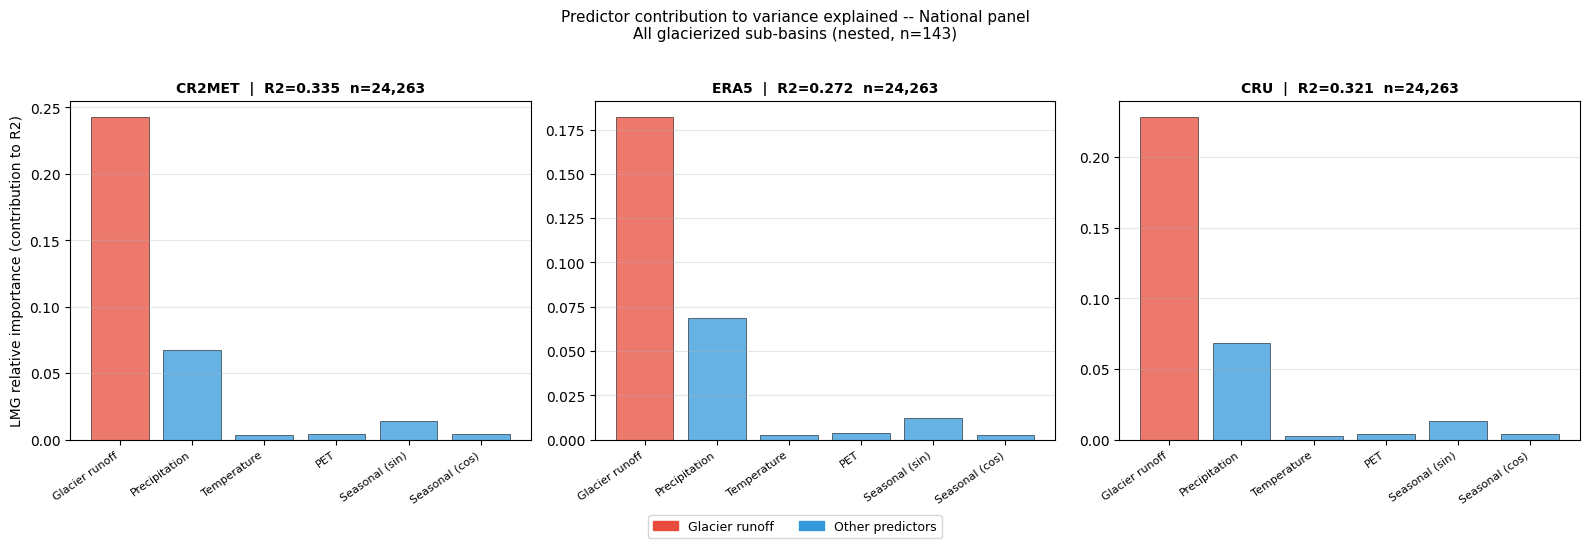


Glacier runoff LMG contribution by dataset:
  CR2MET: LMG=0.2428 (72.4% of total R2)  p_glacier=0.00e+00
  ERA5: LMG=0.1821 (66.8% of total R2)  p_glacier=0.00e+00
  CRU: LMG=0.2284 (71.1% of total R2)  p_glacier=0.00e+00


In [23]:
# ── LMG relative importance (Groemping 2007 / Lindeman-Merenda-Gold 1980) ─
# Averages each predictor's incremental R2 across all orderings of
# predictor entry. Values sum exactly to total R2, unlike squared
# semi-partial correlations, which can over/under-sum when predictors
# are correlated.

from itertools import permutations

def lmg_relative_importance(df, predictors, target='q_m3_mon'):
    sub = df.dropna(subset=predictors + [target]).copy()
    sub = sub[sub[target] > 0]
    X_full = sub[predictors].values
    y      = sub[target].values

    def r2_for(subset_preds):
        if len(subset_preds) == 0:
            return 0.0
        idx = [predictors.index(p) for p in subset_preds]
        X   = X_full[:, idx]
        mod = LinearRegression().fit(X, y)
        pred = mod.predict(X)
        ss_res = np.sum((y - pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        return 1 - ss_res / ss_tot

    lmg = {p: 0.0 for p in predictors}
    all_orders = list(permutations(predictors))
    for order in all_orders:
        r2_prev = 0.0
        entered = []
        for p in order:
            entered.append(p)
            r2_now = r2_for(entered)
            lmg[p] += (r2_now - r2_prev)
            r2_prev = r2_now
    for p in predictors:
        lmg[p] /= len(all_orders)
    return lmg


print('Computing LMG relative importance (6 predictors -> 720 orderings per dataset)...')
LMG_RESULTS = {}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    LMG_RESULTS[ds_name] = lmg_relative_importance(REG_DATA[ds_name], PREDICTORS_A)
    total = sum(LMG_RESULTS[ds_name].values())
    r2    = PANEL_RESULTS[ds_name]['r2']
    print(f'{ds_name}: sum of LMG = {total:.4f}  (R2 = {r2:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    lmg    = LMG_RESULTS[ds_name]
    labels = [PRED_LABELS.get(p, p) for p in PREDICTORS_A]
    vals   = [lmg[p] for p in PREDICTORS_A]
    colors = ['#e74c3c' if p == 'glacier_runoff_m3' else '#3498db' for p in PREDICTORS_A]
    x = np.arange(len(PREDICTORS_A))
    ax.bar(x, vals, color=colors, alpha=0.75, edgecolor='k', lw=0.5)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    r2 = PANEL_RESULTS[ds_name]['r2']; n = PANEL_RESULTS[ds_name]['n']
    ax.set_title(f'{ds_name}  |  R2={r2:.3f}  n={n:,}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    if ds_name == 'CR2MET':
        ax.set_ylabel('LMG relative importance (contribution to R2)', fontsize=10)

fig.legend(handles=[mpatches.Patch(color='#e74c3c', label='Glacier runoff'),
                     mpatches.Patch(color='#3498db', label='Other predictors')],
           loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f'Predictor contribution to variance explained -- National panel\n'
             f'{BASIN_SET_LABEL}', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/national_panel_lmg.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Glacier runoff LMG contribution by dataset:')
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    lmg = LMG_RESULTS[ds_name]['glacier_runoff_m3']
    r2  = PANEL_RESULTS[ds_name]['r2']
    p_glac = PANEL_RESULTS[ds_name]['pval']['glacier_runoff_m3']
    print(f'  {ds_name}: LMG={lmg:.4f} ({lmg/r2*100:.1f}% of total R2)  p_glacier={p_glac:.2e}')

LMG = Lindeman, Merenda, and Gold

To find each predictor's "fair share" of R², you'd ideally look at how much R² increases when that predictor is added to the model — but that increase depends on what order you add predictors in (a variable added first often looks more important than the same variable added last, because it gets credit for variance it shares with other predictors). LMG's fix is to average that incremental contribution across every possible order predictors could be added in, so no single ordering biases the result. That's why the code loops over all permutations(predictors). For 6 predictors that's 720 orderings, each one refit as a mini-regression at every step.

## 5. Cluster-level panel regression + LMG

In [7]:
print(f'Cluster-level panel regressions -- {BASIN_SET_LABEL}')
print('='*95)
print(f'{"Cluster":6s} {"n_obs":7s} {"n_basins":9s} {"R2":6s} '
      f'{"b_glacier":10s} {"p_glacier":10s} {"sig":5s} {"LMG_glac":9s} {"LMG%R2":7s}')
print('-'*95)

CLUSTER_REG = {ds: {} for ds in DATASETS}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    for cl in CLUSTERS:
        cl_gauges = [gid for gid, info in GAUGE_INFO_FRAC.items()
                     if info.get('clusters') and info['clusters'][0] == cl]
        cl_df = REG_DATA[ds_name][REG_DATA[ds_name]['gauge_id'].isin(cl_gauges)].copy()
        cl_df = cl_df.dropna(subset=PREDICTORS_A + ['q_m3_mon'])
        cl_df = cl_df[cl_df['q_m3_mon'] > 0]
        if len(cl_df) < 30:
            if ds_name == 'CR2MET':
                print(f'{cl:6s} {"too few obs (<30)":>30s}')
            continue

        X = cl_df[PREDICTORS_A].values
        y = cl_df['q_m3_mon'].values
        mod    = LinearRegression().fit(X, y)
        y_pred = mod.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2     = 1 - ss_res / ss_tot

        n, k  = len(y), X.shape[1]
        mse   = ss_res / (n - k - 1)
        var_b = mse * np.linalg.inv(X.T @ X).diagonal()
        se    = np.sqrt(var_b)
        t_stat = mod.coef_[0] / se[0]
        p_val  = 2 * stats.t.sf(abs(t_stat), df=n-k-1)
        sig    = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'

        lmg = lmg_relative_importance(cl_df, PREDICTORS_A)
        lmg_glac = lmg['glacier_runoff_m3']
        lmg_pct  = (lmg_glac / r2 * 100) if r2 > 0 else np.nan

        CLUSTER_REG[ds_name][cl] = {
            'r2': r2, 'b_glacier': mod.coef_[0], 'p_glacier': p_val,
            'n_basins': cl_df['gauge_id'].nunique(), 'n_obs': len(cl_df),
            'sig': sig, 'lmg': lmg, 'lmg_glacier': lmg_glac, 'lmg_glacier_pct': lmg_pct,
        }
        if ds_name == 'CR2MET':
            print(f'{cl:6s} {len(cl_df):7,d} {CLUSTER_REG[ds_name][cl]["n_basins"]:9d} '
                  f'{r2:6.3f} {mod.coef_[0]:+10.2f} {p_val:10.4f} {sig:5s} '
                  f'{lmg_glac:9.4f} {lmg_pct:6.1f}%')

print()
print('Cluster R2 across all three datasets:')
print(f'{"Cluster":6s} {"CR2MET":8s} {"ERA5":8s} {"CRU":8s} {"Mean R2"}')
print('-'*40)
for cl in CLUSTERS:
    r2s = [CLUSTER_REG[ds].get(cl, {}).get('r2', np.nan) for ds in ['CR2MET','ERA5','CRU']]
    valid = [r for r in r2s if not np.isnan(r)]
    mean_r2 = np.mean(valid) if valid else np.nan
    r2_str = [f'{r:8.3f}' if not np.isnan(r) else '     nan' for r in r2s]
    print(f'{cl:6s} {r2_str[0]} {r2_str[1]} {r2_str[2]} '
          f'{mean_r2:.3f}' if not np.isnan(mean_r2) else f'{cl:6s} n/a')


Cluster-level panel regressions -- All glacierized sub-basins (nested, n=143)
Cluster n_obs   n_basins  R2     b_glacier  p_glacier  sig   LMG_glac  LMG%R2 
-----------------------------------------------------------------------------------------------
OT3        483         3  0.163      -0.65     0.0001 ***      0.0208   12.7%
DA1      3,870        22  0.095      -0.29     0.0041 **       0.0016    1.7%
DA2      2,076        12  0.312      +2.83     0.0000 ***      0.1634   52.3%
DA3      2,924        16  0.177      +3.33     0.0000 ***      0.0031    1.7%
WA1      7,653        44  0.215     +20.28     0.0000 ***      0.0439   20.4%
WA2      4,468        30  0.462      +2.80     0.0000 ***      0.3988   86.3%
WA3      1,247         7  0.650      +1.75     0.0000 ***      0.5299   81.5%
WA4      1,193         7  0.719      +1.71     0.0000 ***      0.4033   56.1%
WA5                 too few obs (<30)
WA6        349         2  0.490      +1.77     0.6760 ns       0.0146    3.0%

Cluste

### Full LMG breakdown by cluster and dataset

In [8]:
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    print(f'\n{"="*70}\nDATASET: {ds_name}\n{"="*70}')
    for cl in CLUSTERS:
        cl_res = CLUSTER_REG[ds_name].get(cl)
        if cl_res is None:
            print(f'\n{cl}: no results (too few obs)')
            continue
        r2, lmg = cl_res['r2'], cl_res['lmg']
        print(f'\n{cl} ({REGION_LABELS.get(cl, cl)})  R2={r2:.3f}  '
              f'n_basins={cl_res["n_basins"]}  sig={cl_res["sig"]}')
        for p in PREDICTORS_A:
            pct = (lmg[p] / r2 * 100) if r2 > 0 else np.nan
            print(f'  {PRED_LABELS[p]:20s} LMG={lmg[p]:.4f}  ({pct:5.1f}% of R2)')

print(f'\n{"="*70}\nNATIONAL PANEL\n{"="*70}')
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    r2  = PANEL_RESULTS[ds_name]['r2']
    lmg = LMG_RESULTS[ds_name]
    print(f'\n{ds_name}  R2={r2:.3f}  n={PANEL_RESULTS[ds_name]["n"]:,}')
    for p in PREDICTORS_A:
        pct = lmg[p] / r2 * 100
        print(f'  {PRED_LABELS[p]:20s} LMG={lmg[p]:.4f}  ({pct:5.1f}% of R2)')



DATASET: CR2MET

OT3 (Altiplano (OT3))  R2=0.163  n_basins=3  sig=***
  Glacier runoff       LMG=0.0208  ( 12.7% of R2)
  Precipitation        LMG=0.0582  ( 35.6% of R2)
  Temperature          LMG=0.0421  ( 25.8% of R2)
  PET                  LMG=0.0098  (  6.0% of R2)
  Seasonal (sin)       LMG=0.0179  ( 10.9% of R2)
  Seasonal (cos)       LMG=0.0146  (  9.0% of R2)

DA1 (Dry Andes N (DA1))  R2=0.095  n_basins=22  sig=**
  Glacier runoff       LMG=0.0016  (  1.7% of R2)
  Precipitation        LMG=0.0022  (  2.3% of R2)
  Temperature          LMG=0.0632  ( 66.3% of R2)
  PET                  LMG=0.0148  ( 15.5% of R2)
  Seasonal (sin)       LMG=0.0073  (  7.7% of R2)
  Seasonal (cos)       LMG=0.0062  (  6.5% of R2)

DA2 (Dry Andes C (DA2))  R2=0.312  n_basins=12  sig=***
  Glacier runoff       LMG=0.1634  ( 52.3% of R2)
  Precipitation        LMG=0.0310  (  9.9% of R2)
  Temperature          LMG=0.0277  (  8.9% of R2)
  PET                  LMG=0.0445  ( 14.3% of R2)
  Seasonal (sin)

### Optional: seasonality specification sensitivity check

`sin_month`/`cos_month` models the seasonal cycle as one smooth symmetric
wave -- a modeling *choice*, not a fact about the hydrology. This check
asks: does glacier runoff's share of R2 (its LMG%) change much if
seasonality is instead modeled with 11 monthly dummy variables (no shape
assumption at all)?

- If LMG% barely moves between the two specifications, that's reassuring
  -- the "glacier runoff explains X% of variance" finding isn't an
  artifact of how seasonality was modeled.
- If it moves a lot, that's a real caveat to disclose -- part of what
  looks like "glacier signal" could actually be seasonality the sin/cos
  pair failed to capture, leaking into the glacier coefficient instead.

In the original run (all_glacierized basin set) this shifted LMG% by only
a few points per cluster (e.g. WA2: 85.8% vs 84.9%; DA1: 5.9% vs 3.7%) --
reassuring, not a concern. Off by default since it's expensive (Monte
Carlo LMG over 15 predictors). Set the flag below to `True` and rerun this
cell to check it again for the currently-active `BASIN_SET`.

In [9]:
RUN_SEASONALITY_SENSITIVITY = False  # set True to run this check

if RUN_SEASONALITY_SENSITIVITY:
    import random

    def lmg_relative_importance_approx(df, predictors, target='q_m3_mon', n_samples=500, seed=42):
        """Monte Carlo approximation of LMG -- randomly samples orderings
        instead of enumerating all n! (needed once predictor count is large,
        e.g. 4 numeric + 11 monthly dummies = 15 predictors)."""
        rng = random.Random(seed)
        sub = df.dropna(subset=predictors + [target]).copy()
        sub = sub[sub[target] > 0]
        X_full, y = sub[predictors].values, sub[target].values

        def r2_for(idx_list):
            if len(idx_list) == 0:
                return 0.0
            X = X_full[:, idx_list]
            mod = LinearRegression().fit(X, y)
            pred = mod.predict(X)
            ss_res = np.sum((y - pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            return 1 - ss_res / ss_tot

        idx_all = list(range(len(predictors)))
        lmg = {p: 0.0 for p in predictors}
        for _ in range(n_samples):
            order = idx_all.copy(); rng.shuffle(order)
            r2_prev, entered = 0.0, []
            for idx in order:
                entered.append(idx)
                r2_now = r2_for(entered)
                lmg[predictors[idx]] += (r2_now - r2_prev)
                r2_prev = r2_now
        for p in predictors:
            lmg[p] /= n_samples
        return lmg

    MONTH_DUMMY_COLS = [f'month_{m}' for m in range(2, 13)]  # month 1 = reference
    PREDICTORS_B = ['glacier_runoff_m3', 'precip_mm', 'tmean_C', 'pet_mm'] + MONTH_DUMMY_COLS

    REG_DATA_DUMMY = {}
    for ds_name in DATASETS:
        df = REG_DATA[ds_name].copy()
        for m in range(2, 13):
            df[f'month_{m}'] = (df['month'] == m).astype(int)
        REG_DATA_DUMMY[ds_name] = df

    print(f'Comparing glacier runoff LMG%: sin/cos vs. monthly dummies -- {BASIN_SET_LABEL}')
    print('(Monte Carlo LMG, 2000 samples per cluster/dataset)')
    print('='*80)
    print(f'{"Cluster":6s} {"Dataset":8s} {"R2 (sincos)":12s} {"LMG% sincos":12s} '
          f'{"R2 (dummy)":11s} {"LMG% dummy":11s}')
    print('-'*80)

    CLUSTER_REG_DUMMY = {}
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        CLUSTER_REG_DUMMY[ds_name] = {}
        for cl in CLUSTERS:
            cl_gauges = [gid for gid, info in GAUGE_INFO_FRAC.items()
                         if info.get('clusters') and info['clusters'][0] == cl]
            cl_df = REG_DATA_DUMMY[ds_name][REG_DATA_DUMMY[ds_name]['gauge_id'].isin(cl_gauges)].copy()
            cl_df = cl_df.dropna(subset=PREDICTORS_B + ['q_m3_mon'])
            cl_df = cl_df[cl_df['q_m3_mon'] > 0]
            if len(cl_df) < 30:
                continue

            X, y = cl_df[PREDICTORS_B].values, cl_df['q_m3_mon'].values
            mod = LinearRegression().fit(X, y)
            y_pred = mod.predict(X)
            ss_res = np.sum((y - y_pred)**2)
            r2 = 1 - ss_res / np.sum((y - y.mean())**2)

            lmg = lmg_relative_importance_approx(cl_df, PREDICTORS_B, n_samples=2000, seed=42)
            lmg_glac = lmg['glacier_runoff_m3']
            lmg_pct = (lmg_glac / r2 * 100) if r2 > 0 else np.nan
            CLUSTER_REG_DUMMY[ds_name][cl] = {'r2': r2, 'lmg': lmg, 'lmg_glacier': lmg_glac,
                                               'lmg_glacier_pct': lmg_pct}

            r2_sc  = CLUSTER_REG[ds_name].get(cl, {}).get('r2', np.nan)
            pct_sc = CLUSTER_REG[ds_name].get(cl, {}).get('lmg_glacier_pct', np.nan)
            print(f'{cl:6s} {ds_name:8s} {r2_sc:12.3f} {pct_sc:11.1f}% '
                  f'{r2:11.3f} {lmg_pct:10.1f}%')

    print()
    print('If LMG% shifts substantially between sincos and dummy versions,')
    print('the seasonality specification matters for the glacier importance')
    print('estimate and should be reported/justified explicitly in the paper.')
else:
    print('Seasonality sensitivity check skipped (RUN_SEASONALITY_SENSITIVITY = False)')


Seasonality sensitivity check skipped (RUN_SEASONALITY_SENSITIVITY = False)


## 6. Per-basin regression + significance

Uses bootstrap confidence intervals (rather than a plain p-value cutoff)
to flag which basins show a significant glacier signal -- the CI excluding
zero is the significance criterion used throughout the rest of this
notebook.

In [10]:
def run_basin_regression_with_ci(df, predictors, target='q_m3s', n_boot=1000):
    sub = df[predictors + [target]].dropna()
    sub = sub[sub[target] > 0] if target == 'q_m3s' else sub
    if len(sub) < 24:
        return None

    X, y = sub[predictors].values, sub[target].values
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_std  = scaler.fit_transform(X)

    reg    = LinearRegression().fit(X_std, y)
    y_pred = reg.predict(X_std)
    r2     = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

    rng = np.random.default_rng(42)
    boot_coefs = np.zeros((n_boot, len(predictors)))
    for i in range(n_boot):
        idx = rng.integers(0, len(sub), len(sub))
        reg_b = LinearRegression().fit(X_std[idx], y[idx])
        boot_coefs[i] = reg_b.coef_
    ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
    ci_hi = np.percentile(boot_coefs, 97.5, axis=0)

    return {'n': len(sub), 'r2': r2,
            'coef': dict(zip(predictors, reg.coef_)),
            'ci_lo': dict(zip(predictors, ci_lo)),
            'ci_hi': dict(zip(predictors, ci_hi))}


print('Per-basin regressions with bootstrap CI (all datasets)...')
PER_BASIN = {}
for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    rows = []
    df = REG_DATA[ds_name]
    for gauge_id, info in GAUGE_INFO_FRAC.items():
        sub = df[df['gauge_id'] == gauge_id].copy()
        sub = sub.dropna(subset=PREDICTORS_A + ['q_m3s'])
        sub = sub[sub['q_m3s'] > 0]
        result = run_basin_regression_with_ci(sub, PREDICTORS_A, target='q_m3s')
        if result is None:
            continue
        sig = (result['ci_lo']['glacier_runoff_m3'] > 0 or
               result['ci_hi']['glacier_runoff_m3'] < 0)
        rows.append({
            'gauge_id': gauge_id, 'gauge_name': info['gauge_name'][:35],
            'cluster': info['clusters'][0] if info.get('clusters') else 'unknown',
            'lat': info['cen_lat'], 'glacier_area_km2': info['glacier_area_km2'],
            'basin_area_km2': info.get('basin_area_km2', np.nan),
            'n_obs': result['n'], 'r2': result['r2'],
            'b_glacier': result['coef']['glacier_runoff_m3'],
            'ci_lo_glacier': result['ci_lo']['glacier_runoff_m3'],
            'ci_hi_glacier': result['ci_hi']['glacier_runoff_m3'],
            'sig': sig,
        })
    PER_BASIN[ds_name] = pd.DataFrame(rows)
    if len(PER_BASIN[ds_name]):
        n_sig = PER_BASIN[ds_name]['sig'].sum()
        n_tot = len(PER_BASIN[ds_name])
        print(f'{ds_name}: {n_sig}/{n_tot} significant ({n_sig/n_tot*100:.0f}%)  '
              f'median R2={PER_BASIN[ds_name]["r2"].median():.3f}')
    PER_BASIN[ds_name].to_csv(f'{REG_DIR}/per_basin_regression_{ds_name}.csv', index=False)

sig_cr2 = set(PER_BASIN['CR2MET'][PER_BASIN['CR2MET']['sig']]['gauge_id'])
sig_era = set(PER_BASIN['ERA5'][PER_BASIN['ERA5']['sig']]['gauge_id'])
sig_cru = set(PER_BASIN['CRU'][PER_BASIN['CRU']['sig']]['gauge_id'])
robust  = sig_cr2 & sig_era & sig_cru
print(f'\nRobust across all 3 datasets: {len(robust)} basins')
if len(robust):
    robust_df = PER_BASIN['CR2MET'][PER_BASIN['CR2MET']['gauge_id'].isin(robust)].sort_values('lat')
    print(robust_df[['gauge_id','gauge_name','cluster','lat','r2','glacier_area_km2']]
          .to_string(index=False))


Per-basin regressions with bootstrap CI (all datasets)...
CR2MET: 34/143 significant (24%)  median R2=0.586
ERA5: 37/143 significant (26%)  median R2=0.588
CRU: 31/143 significant (22%)  median R2=0.584

Robust across all 3 datasets: 11 basins
gauge_id                          gauge_name cluster        lat       r2  glacier_area_km2
12582001       Rio San Juan En Desembocadura     WA6 -53.580900 0.586477             0.576
12291001           Rio Prat En Desembocadura     WA4 -51.473000 0.333673             0.063
12287001        Rio Grey Antes Junta Serrano     WA3 -50.952067 0.880875           457.613
12280002      Rio Paine En Parque Nacional 2     WA4 -50.855287 0.879304            31.956
12284003        Rio Vizcachas En Cerro Guido     WA4 -50.742800 0.401723             0.628
12284007 Rio Las Chinas Antes Desague Del To     WA3 -50.728790 0.431421             1.920
12284006       Rio Las Chinas En Cerro Guido     WA3 -50.714780 0.366485             1.292
11711000    Rio Pascua Ante 

In [11]:
# ── Per-basin significance summary by cluster ───────────────────────────
print(f'Per-basin significance and R2 by cluster -- {BASIN_SET_LABEL}')
print(f'{"Cluster":6s} {"n_basins":9s} {"CR2MET sig%":12s} {"ERA5 sig%":10s} '
      f'{"CRU sig%":9s} {"CR2MET R2":10s} {"ERA5 R2":8s} {"CRU R2"}')
print('-'*85)
for cl in CLUSTERS:
    cr2_cl = PER_BASIN['CR2MET'][PER_BASIN['CR2MET']['cluster'] == cl]
    era_cl = PER_BASIN['ERA5'][PER_BASIN['ERA5']['cluster'] == cl]
    cru_cl = PER_BASIN['CRU'][PER_BASIN['CRU']['cluster'] == cl]
    if len(cr2_cl) == 0:
        continue
    def pct_sig(d): return f'{d["sig"].mean()*100:.0f}%' if len(d) else 'n/a'
    def med_r2(d):  return f'{d["r2"].median():.3f}' if len(d) else 'n/a'
    print(f'{cl:6s} {len(cr2_cl):9d} {pct_sig(cr2_cl):12s} {pct_sig(era_cl):10s} '
          f'{pct_sig(cru_cl):9s} {med_r2(cr2_cl):10s} {med_r2(era_cl):8s} {med_r2(cru_cl)}')


Per-basin significance and R2 by cluster -- All glacierized sub-basins (nested, n=143)
Cluster n_basins  CR2MET sig%  ERA5 sig%  CRU sig%  CR2MET R2  ERA5 R2  CRU R2
-------------------------------------------------------------------------------------
OT3            3 33%          0%         33%       0.206      0.201    0.221
DA1           22 18%          0%         14%       0.115      0.107    0.107
DA2           12 25%          17%        8%        0.406      0.410    0.397
DA3           16 25%          25%        25%       0.536      0.549    0.540
WA1           44 11%          23%        18%       0.723      0.727    0.727
WA2           30 17%          30%        13%       0.652      0.661    0.656
WA3            7 71%          86%        86%       0.776      0.785    0.733
WA4            7 71%          57%        43%       0.466      0.455    0.476
WA6            2 100%         100%       50%       0.558      0.568    0.521


## 7. What controls per-basin significance?

Compares significant vs. non-significant basins across basin/glacier
characteristics (elevation, snow fraction, baseflow index, ice volume,
climate). Includes a WA1-specific deep dive (the "paradox" cluster, where
the *least* glacierized basins showed the strongest signal -- driven by
absence of competing snowmelt, not glacier size) and an all-Chile
version that reveals three distinct regional mechanisms.

In [12]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

attrs = pd.read_csv(f'{CAMELS_FULL}/catchment_attributes.csv', dtype={'gauge_id': str})
gauge_coords = attrs[['gauge_id','gauge_lat','gauge_lon','outlet_camels_elev',
                      'mean_elev','baseflow_index_1979_2010',
                      'frac_snow_cr2met_1979_2010']].copy()

glac_stats_all = []
for cl in CLUSTERS:
    path = f'{OUTPUT_ROOT}/CR2MET/{cl}/RGI_{cl}/b_080/L3/summary/glacier_statistics__{cl}.csv'
    if os.path.exists(path):
        df_cl = pd.read_csv(path); df_cl['cluster'] = cl
        glac_stats_all.append(df_cl)
if glac_stats_all:
    glac_stats = pd.concat(glac_stats_all, ignore_index=True)
    print(f'Glacier statistics loaded: {len(glac_stats)} glaciers across {len(glac_stats_all)} clusters')
else:
    glac_stats = pd.DataFrame(columns=['rgi_id','inv_volume_km3'])
    print('WARNING: no glacier_statistics files found -- ice volume fields will be NaN')

rgi_bna = pd.read_csv(RGI_PATH)
rgi_all = rgi_bna.merge(glac_stats[['rgi_id','inv_volume_km3']],
                        left_on='RGIId', right_on='rgi_id', how='left')

SUMMER, WINTER = [12, 1, 2], [6, 7, 8]

rows = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    gid = str(gauge_id)
    rgi_ids_here = set(info.get('rgi_ids', []))
    rgi_here = rgi_all[rgi_all['RGIId'].isin(rgi_ids_here)] if rgi_ids_here else rgi_all.iloc[0:0]

    if len(rgi_here) > 0 and rgi_here['Area'].sum() > 0:
        w = rgi_here['Area'].values
        glac_lon = np.average(rgi_here['CenLon'].values, weights=w)
        glac_lat = np.average(rgi_here['CenLat'].values, weights=w)
        ice_vol  = rgi_here['inv_volume_km3'].sum()
    else:
        glac_lon = glac_lat = ice_vol = np.nan

    gc = gauge_coords[gauge_coords['gauge_id'] == gid]
    if len(gc):
        gauge_lat, gauge_lon = gc['gauge_lat'].values[0], gc['gauge_lon'].values[0]
        outlet_elev, mean_elev = gc['outlet_camels_elev'].values[0], gc['mean_elev'].values[0]
        bfi, frac_snow = gc['baseflow_index_1979_2010'].values[0], gc['frac_snow_cr2met_1979_2010'].values[0]
    else:
        gauge_lat = gauge_lon = outlet_elev = mean_elev = bfi = frac_snow = np.nan

    if not any(np.isnan([glac_lon, glac_lat, gauge_lon, gauge_lat])):
        dist_km = haversine_km(glac_lon, glac_lat, gauge_lon, gauge_lat)
    else:
        dist_km = np.nan

    row = {
        'gauge_id': gauge_id, 'gauge_name': info['gauge_name'][:35],
        'lat': info['cen_lat'], 'cluster': info['clusters'][0] if info.get('clusters') else 'unknown',
        'basin_area_km2': info.get('basin_area_km2', np.nan),
        'glacier_area_km2': info['glacier_area_km2'],
        'glac_pct': info['glacier_area_km2'] / info['basin_area_km2'] * 100
                    if info.get('basin_area_km2') else np.nan,
        'ice_vol_km3': ice_vol, 'dist_glac_gauge_km': dist_km,
        'outlet_elev_m': outlet_elev, 'mean_basin_elev_m': mean_elev,
        'baseflow_index': bfi, 'frac_snow': frac_snow,
    }
    for df, prefix in [(precip_wide,'precip'), (tmean_wide,'tmean')]:
        if gid not in df.columns:
            for p in ['ann','summer','winter']:
                row[f'{prefix}_{p}'] = np.nan
            continue
        for period, months in [('ann', list(range(1,13))), ('summer', SUMMER), ('winter', WINTER)]:
            if prefix == 'precip':
                row[f'{prefix}_{period}'] = df[df['month'].isin(months)].groupby('year')[gid].sum().mean()
            else:
                row[f'{prefix}_{period}'] = df[df['month'].isin(months)][gid].dropna().mean()

    res = RESULTS['CR2MET'].get(gauge_id)
    if res is not None:
        m, cy = res['monthly'], res.get('complete_years', info.get('complete_years', YEARS))
        mc = m[m['year'].isin(cy)]
        row['q_ann_km3']    = mc.groupby('year')['q_m3_mon'].sum().mean() / 1e9
        row['q_summer_km3'] = mc[mc['month'].isin(SUMMER)].groupby('year')['q_m3_mon'].sum().mean() / 1e9
        row['q_winter_km3'] = mc[mc['month'].isin(WINTER)].groupby('year')['q_m3_mon'].sum().mean() / 1e9
    else:
        row['q_ann_km3'] = row['q_summer_km3'] = row['q_winter_km3'] = np.nan

    rows.append(row)

df_all_chars = pd.DataFrame(rows)

df_cr2_sig = PER_BASIN['CR2MET'][['gauge_id','sig','b_glacier','r2']].rename(
    columns={'sig':'sig_cr2','b_glacier':'beta_cr2','r2':'r2_cr2'})
df_all_chars = df_all_chars.merge(df_cr2_sig, on='gauge_id', how='left')
for ds, col in [('ERA5','sig_era5'), ('CRU','sig_cru')]:
    df_ds_sig = PER_BASIN[ds][['gauge_id','sig']].rename(columns={'sig': col})
    df_all_chars = df_all_chars.merge(df_ds_sig, on='gauge_id', how='left')

df_all_chars['n_sig']   = df_all_chars[['sig_cr2','sig_era5','sig_cru']].sum(axis=1)
df_all_chars['robust']  = df_all_chars['n_sig'] == 3
df_all_chars['any_sig'] = df_all_chars['n_sig'] >= 1

df_all_chars.to_csv(f'{REG_DIR}/basin_characteristics.csv', index=False)
print(f'Saved: {REG_DIR}/basin_characteristics.csv')
print(f'Total basins: {len(df_all_chars)}  |  Significant (CR2MET): {df_all_chars["sig_cr2"].sum()}  '
      f'|  Robust (all 3): {df_all_chars["robust"].sum()}')


Glacier statistics loaded: 13246 glaciers across 10 clusters
Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/regression/all_glacierized/basin_characteristics.csv
Total basins: 143  |  Significant (CR2MET): 34  |  Robust (all 3): 11


In [13]:
# ── WA1 deep dive (if present in this basin set) ────────────────────────
chars = [
    ('basin_area_km2',     'Basin area (km2)'),
    ('glacier_area_km2',   'Glacier area (km2)'),
    ('glac_pct',           'Glacier % of basin'),
    ('ice_vol_km3',        'Total ice volume (km3)'),
    ('dist_glac_gauge_km', 'Glacier-to-gauge distance (km)'),
    ('outlet_elev_m',      'Gauge outlet elevation (m)'),
    ('mean_basin_elev_m',  'Mean basin elevation (m)'),
    ('baseflow_index',     'Baseflow index'),
    ('frac_snow',          'Fraction precip as snow'),
    ('precip_ann',         'Mean annual precip (mm/yr)'),
    ('precip_summer',      'Mean summer precip DJF (mm)'),
    ('tmean_ann',          'Mean annual temp (C)'),
    ('tmean_summer',       'Mean summer temp DJF (C)'),
    ('tmean_winter',       'Mean winter temp JJA (C)'),
    ('q_ann_km3',          'Mean annual Q (km3/yr)'),
    ('q_summer_km3',       'Mean summer Q DJF (km3/yr)'),
    ('q_winter_km3',       'Mean winter Q JJA (km3/yr)'),
]

wa1 = df_all_chars[df_all_chars['cluster'] == 'WA1']
if len(wa1) >= 6:
    sig, ns = wa1[wa1['sig_cr2'] == True], wa1[wa1['sig_cr2'] == False]
    print(f'WA1: significant vs non-significant basins (CR2MET, n_sig={len(sig)}, n_ns={len(ns)})')
    print(f'{"Characteristic":38s} {"Sig":15s} {"Not sig":15s} {"Diff"}')
    print('-'*80)
    for col, label in chars:
        s, n = sig[col].median(), ns[col].median()
        diff = f'{(s-n)/abs(n)*100:+.0f}%' if (n not in (0, np.nan) and not np.isnan(s) and not np.isnan(n)) else 'n/a'
        print(f'{label:38s} {s:15.3f} {n:15.3f} {diff}')
else:
    print('WA1 has too few basins in this basin set for a meaningful comparison '
          '(expected with grouped_main or leaf_only depending on how many WA1 '
          'main/leaf basins exist).')


WA1: significant vs non-significant basins (CR2MET, n_sig=5, n_ns=39)
Characteristic                         Sig             Not sig         Diff
--------------------------------------------------------------------------------
Basin area (km2)                              4385.546        1379.354 +218%
Glacier area (km2)                               9.585          13.626 -30%
Glacier % of basin                               0.709           0.788 -10%
Total ice volume (km3)                           0.629           0.580 +8%
Glacier-to-gauge distance (km)                  76.389          32.609 +134%
Gauge outlet elevation (m)                      87.000         394.000 -78%
Mean basin elevation (m)                       784.996        1262.176 -38%
Baseflow index                                   0.592           0.695 -15%
Fraction precip as snow                          0.004           0.053 -93%
Mean annual precip (mm/yr)                    1966.618        1985.212 -1%
Mean summer p

ALL BASINS: significant vs non-significant (CR2MET) -- All glacierized sub-basins (nested, n=143)

Characteristic                         Sig (n=34)      Not sig (n=109) Diff
--------------------------------------------------------------------------------
Basin area (km2)                              1173.095        2434.302 -52%
Glacier area (km2)                               4.909          20.490 -76%
Glacier % of basin                               0.413           0.788 -48%
Total ice volume (km3)                           0.184           0.923 -80%
Glacier-to-gauge distance (km)                  45.391          41.709 +9%
Gauge outlet elevation (m)                     129.000         395.000 -67%
Mean basin elevation (m)                       904.530        1382.498 -35%
Baseflow index                                   0.729           0.713 +2%
Fraction precip as snow                          0.105           0.104 +1%
Mean annual precip (mm/yr)                     951.676        1

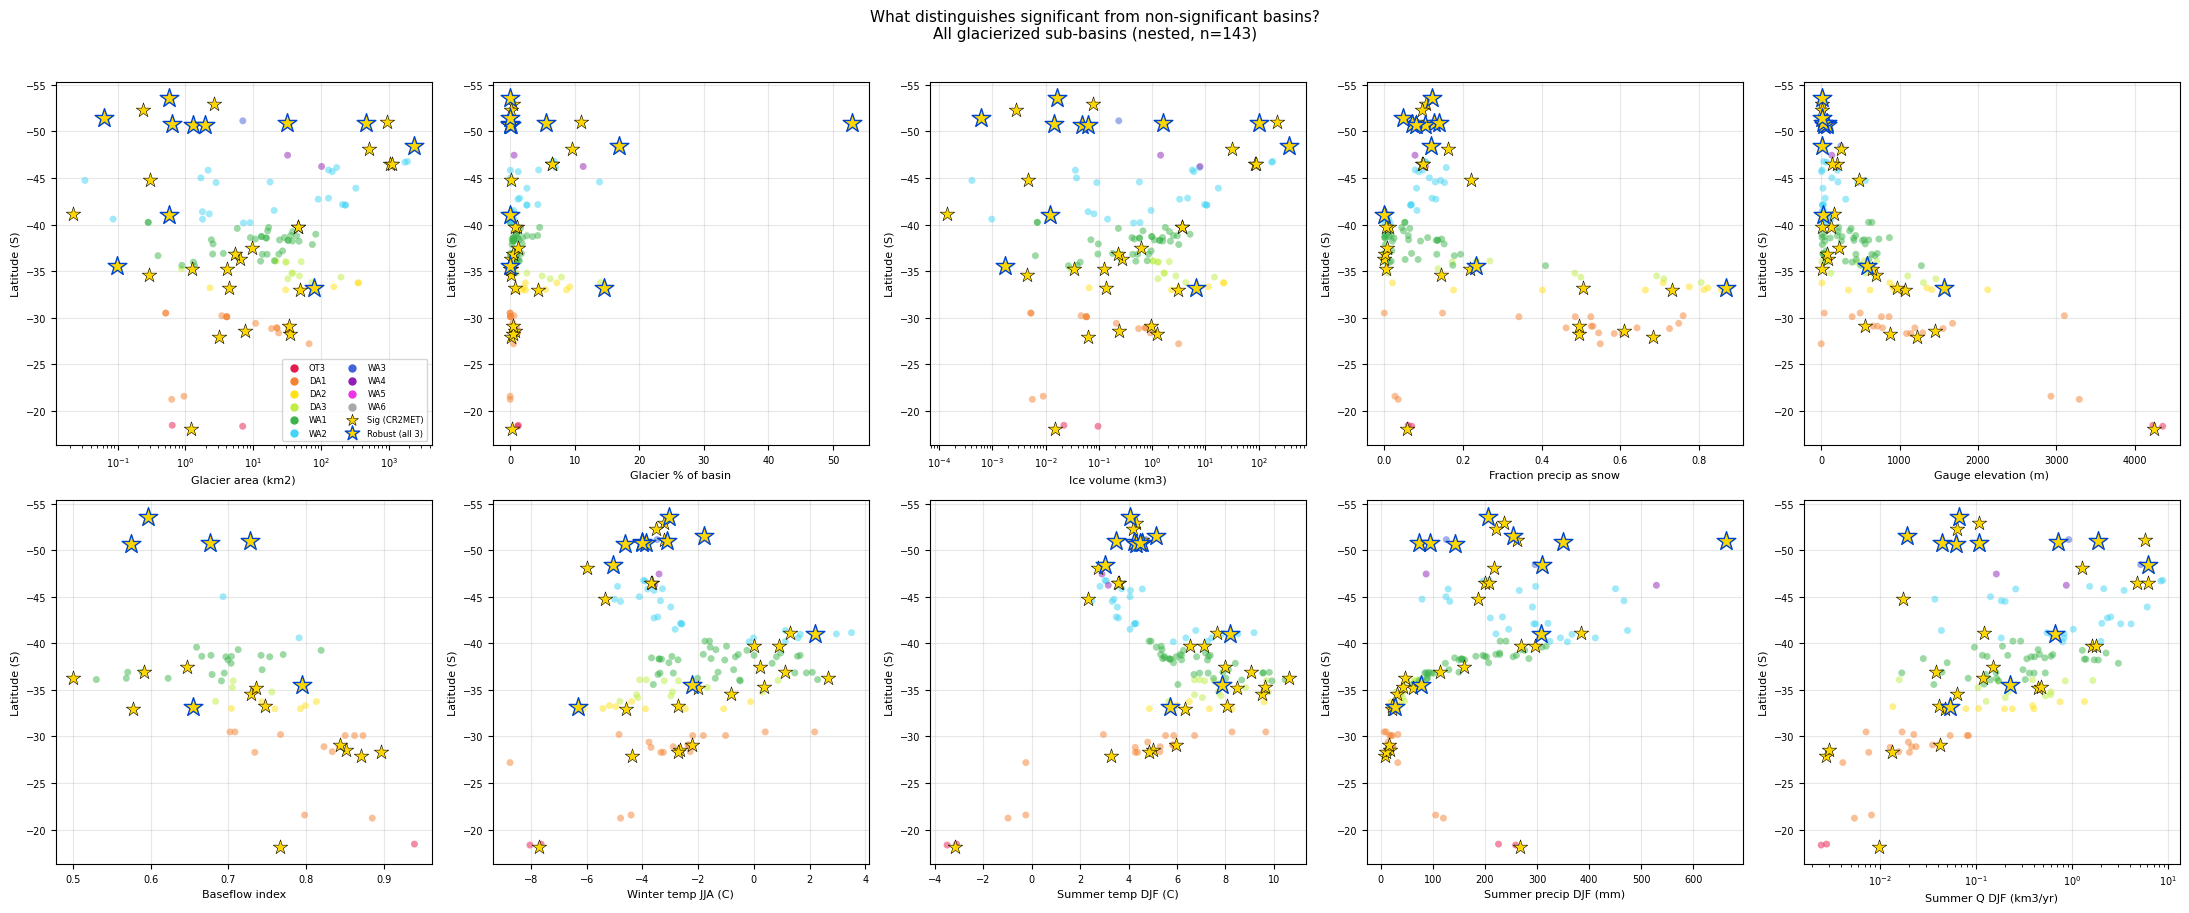

In [14]:
# ── All-Chile diagnostic: significant vs non-significant, and by cluster ─
print(f'ALL BASINS: significant vs non-significant (CR2MET) -- {BASIN_SET_LABEL}')
sig = df_all_chars[df_all_chars['sig_cr2'] == True]
ns  = df_all_chars[df_all_chars['sig_cr2'] == False]
print(f'\n{"Characteristic":38s} {"Sig (n={})".format(len(sig)):15s} '
      f'{"Not sig (n={})".format(len(ns)):15s} {"Diff"}')
print('-'*80)
for col, label in chars:
    s, n = sig[col].median(), ns[col].median()
    diff = f'{(s-n)/abs(n)*100:+.0f}%' if (n not in (0, np.nan) and not np.isnan(s) and not np.isnan(n)) else 'n/a'
    print(f'{label:38s} {s:15.3f} {n:15.3f} {diff}')

print('\n\nBY CLUSTER:')
key_chars = ['glacier_area_km2','glac_pct','ice_vol_km3','frac_snow',
             'outlet_elev_m','baseflow_index','tmean_winter','q_summer_km3']
for cl in CLUSTERS:
    df_cl = df_all_chars[df_all_chars['cluster'] == cl]
    if len(df_cl) < 4:
        continue
    sig_cl, ns_cl = df_cl[df_cl['sig_cr2']==True], df_cl[df_cl['sig_cr2']==False]
    print(f'\n{cl} ({len(sig_cl)}/{len(df_cl)} significant):')
    for col in key_chars:
        s, n = sig_cl[col].median(), ns_cl[col].median()
        if len(sig_cl)==0 or np.isnan(s) or np.isnan(n) or n == 0:
            continue
        print(f'  {col:30s} {s:10.3f} {n:10.3f} {(s-n)/abs(n)*100:+.0f}%')

# Figure
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes_flat = axes.flatten()
plot_vars = [
    ('glacier_area_km2', 'Glacier area (km2)', True), ('glac_pct', 'Glacier % of basin', False),
    ('ice_vol_km3', 'Ice volume (km3)', True), ('frac_snow', 'Fraction precip as snow', False),
    ('outlet_elev_m', 'Gauge elevation (m)', False), ('baseflow_index', 'Baseflow index', False),
    ('tmean_winter', 'Winter temp JJA (C)', False), ('tmean_summer', 'Summer temp DJF (C)', False),
    ('precip_summer', 'Summer precip DJF (mm)', False), ('q_summer_km3', 'Summer Q DJF (km3/yr)', True),
]
cluster_colors = {'OT3':'#e6194b','DA1':'#f58231','DA2':'#ffe119','DA3':'#bfef45',
                  'WA1':'#3cb44b','WA2':'#42d4f4','WA3':'#4363d8','WA4':'#911eb4',
                  'WA5':'#f032e6','WA6':'#a9a9a9'}
for ax, (col, label, use_log) in zip(axes_flat, plot_vars):
    for cl in CLUSTERS:
        grp = df_all_chars[(df_all_chars['cluster']==cl) & (df_all_chars['sig_cr2']==False)]
        vals = grp[col].dropna(); lats = grp.loc[vals.index, 'lat']
        if len(vals) == 0: continue
        ax.scatter(vals, lats, c=cluster_colors.get(cl,'#999'), s=25, alpha=0.5, edgecolors='none', zorder=2)
    sig_grp = df_all_chars[df_all_chars['sig_cr2']==True]
    sv, sl = sig_grp[col].dropna(), sig_grp.loc[sig_grp[col].dropna().index, 'lat']
    ax.scatter(sv, sl, marker='*', c='gold', s=120, edgecolors='k', lw=0.4, zorder=5)
    rob_grp = df_all_chars[df_all_chars['robust']==True]
    rv, rl = rob_grp[col].dropna(), rob_grp.loc[rob_grp[col].dropna().index, 'lat']
    ax.scatter(rv, rl, marker='*', c='gold', s=200, edgecolors='#0044cc', lw=1.0, zorder=6)
    ax.set_xlabel(label, fontsize=8); ax.set_ylabel('Latitude (S)', fontsize=8)
    ax.invert_yaxis(); ax.grid(True, alpha=0.3)
    if use_log: ax.set_xscale('log')
    ax.tick_params(labelsize=7)
handles = [plt.scatter([],[], c=cluster_colors[cl], s=25, label=cl) for cl in CLUSTERS]
handles += [plt.scatter([],[], marker='*', c='gold', s=80, edgecolors='k', lw=0.4, label='Sig (CR2MET)'),
            plt.scatter([],[], marker='*', c='gold', s=120, edgecolors='#0044cc', lw=1.0, label='Robust (all 3)')]
axes_flat[0].legend(handles=handles, fontsize=6, loc='lower right', ncol=2)
for ax in axes_flat[len(plot_vars):]: ax.set_visible(False)
fig.suptitle(f'What distinguishes significant from non-significant basins?\n{BASIN_SET_LABEL}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/all_basins_significance_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretive summary from the source analysis (all_glacierized basin
set), kept as documented findings -- re-verify against whichever basin set
is currently active before citing:**

- **National pattern:** significant basins tend to be smaller, drier,
  lower-elevation systems where glacier signal is large relative to total
  flow -- not the large wet Patagonian systems where precipitation
  dominates.
- **Dry Andes (DA1):** significance driven by glacier *size* -- bigger
  glaciers produce more melt, detectable above near-zero precipitation
  noise.
- **Wet Andes transition zone (WA1, DA3):** significance driven by
  *thermal regime* -- warmer, lower-elevation, low-snow basins have no
  competing snowmelt signal. The most glacierized WA1 volcanic basins
  (Allipen, Trancura, Cautin, Lonquimay) paradoxically show the *weakest*
  signal, masked by snowmelt and volcanic-aquifer baseflow.
- **Patagonia (WA3, WA4):** significance driven by *glacierization
  relative to total flow* -- the largest, most glacierized systems (Baker,
  Pascua) are non-significant because precipitation dominates total Q;
  smaller basins with a large glacier fraction of a small total flow show
  the clearest signal.
- Statistical significance and physical magnitude are different things:
  a small glacier can be a *statistically detectable* driver of monthly
  variability without being a *physically dominant* water source. Keep
  this distinction explicit in the paper -- detecting signal is not the
  same as claiming basins are glacier-dependent for water management.


In [15]:
# ── Sanity check: basins with tiny glacier area but robust/near-robust
# significance -- worth a second look before over-interpreting ────────────
suspicious = df_all_chars[
    (df_all_chars['glacier_area_km2'] < 5) & (df_all_chars['n_sig'] >= 2)
].sort_values('glacier_area_km2')

print(f'Basins with glacier area < 5 km2 but n_sig >= 2 ({len(suspicious)} found):')
for _, row in suspicious.iterrows():
    res_cr2 = RESULTS['CR2MET'].get(row['gauge_id'])
    ann_frac = np.nan
    if res_cr2 is not None:
        m, cy = res_cr2['monthly'], res_cr2.get('complete_years', YEARS)
        ann = m[m['year'].isin(cy)].groupby('year').agg(
            glac=('glacier_runoff_m3','sum'), q=('q_m3_mon','sum'))
        ann = ann[ann['q'] > 0]
        ann_frac = (ann['glac']/ann['q']).mean()*100 if len(ann) else np.nan
    print(f'{row["gauge_id"]:10s} {row["gauge_name"]:35s} '
          f'glac={row["glacier_area_km2"]:.2f} km2  basin={row["basin_area_km2"]:.0f} km2  '
          f'mean_ann_frac(CR2MET)={ann_frac:.2f}%  n_sig={row["n_sig"]:.0f}  cluster={row["cluster"]}')

print()
print('These are cases where the glacier contribution is a tiny physical fraction')
print('of streamflow (often <1%) but is still a statistically consistent enough')
print('seasonal signal to register as significant. Not a modeling artifact --')
print('statistical detectability and physical importance are simply different')
print('questions. Frame accordingly in the paper.')


Basins with glacier area < 5 km2 but n_sig >= 2 (14 found):
12291001   Rio Prat En Desembocadura           glac=0.06 km2  basin=220 km2  mean_ann_frac(CR2MET)=0.13%  n_sig=3  cluster=WA4
7115001    Rio Palos En Junta Con Colorado     glac=0.10 km2  basin=490 km2  mean_ann_frac(CR2MET)=0.05%  n_sig=3  cluster=DA3
12452001   Rio Perez En Desembocadura          glac=0.24 km2  basin=308 km2  mean_ann_frac(CR2MET)=0.12%  n_sig=2  cluster=WA4
6013001    Rio Claro En Hacienda Las Nieves    glac=0.29 km2  basin=245 km2  mean_ann_frac(CR2MET)=0.38%  n_sig=2  cluster=DA3
11143002   Rio Moro Antes Junta Rio Cisnes     glac=0.30 km2  basin=134 km2  mean_ann_frac(CR2MET)=0.48%  n_sig=2  cluster=WA2
10344003   Rio Rahue Antes Junta Rio Negro     glac=0.56 km2  basin=2178 km2  mean_ann_frac(CR2MET)=0.05%  n_sig=3  cluster=WA2
12582001   Rio San Juan En Desembocadura       glac=0.58 km2  basin=864 km2  mean_ann_frac(CR2MET)=0.12%  n_sig=3  cluster=WA6
12284003   Rio Vizcachas En Cerro Guido        gla

## 8. Noah's question -- gauged basins with <=100 km2 glacier area

Gauged basins with <=100 km2 glacier area: 121 (of 143 total, all_glacierized)
Latitude range: -53.6S to -18.1S
Clusters represented: ['DA1', 'DA2', 'DA3', 'OT3', 'WA1', 'WA2', 'WA3', 'WA4', 'WA6']


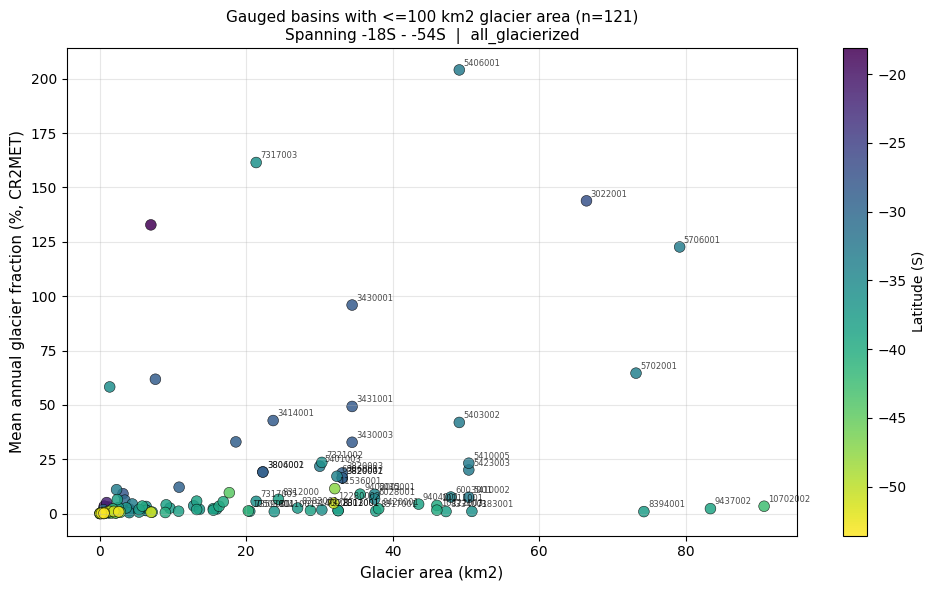

In [16]:
small_glac = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    if info['glacier_area_km2'] > 100:
        continue
    res = RESULTS['CR2MET'].get(gauge_id)
    mean_frac = np.nan
    if res is not None:
        m, cy = res['monthly'], res.get('complete_years', info.get('complete_years', YEARS))
        ann = m[m['year'].isin(cy)].groupby('year').agg(
            glac=('glacier_runoff_m3','sum'), q=('q_m3_mon','sum'))
        ann = ann[ann['q'] > 0]
        mean_frac = (ann['glac']/ann['q']).mean()*100 if len(ann) else np.nan
    small_glac.append({
        'gauge_id': gauge_id, 'gauge_name': info['gauge_name'][:40], 'lat': info['cen_lat'],
        'cluster': info['clusters'][0] if info.get('clusters') else 'unknown',
        'glacier_area_km2': info['glacier_area_km2'],
        'basin_area_km2': info.get('basin_area_km2', np.nan),
        'glac_pct_basin': info['glacier_area_km2'] / info['basin_area_km2'] * 100
                          if info.get('basin_area_km2') else np.nan,
        'mean_ann_frac_pct': mean_frac,
    })

noah_df = pd.DataFrame(small_glac).sort_values('lat', ascending=False)
print(f'Gauged basins with <=100 km2 glacier area: {len(noah_df)} (of {len(GAUGE_INFO_FRAC)} total, {BASIN_SET})')
print(f'Latitude range: {noah_df["lat"].min():.1f}S to {noah_df["lat"].max():.1f}S')
print(f'Clusters represented: {sorted(noah_df["cluster"].unique())}')
noah_df.to_csv(f'{REG_DIR}/noah_small_glacierized_basins.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(noah_df['glacier_area_km2'], noah_df['mean_ann_frac_pct'],
                c=noah_df['lat'], cmap='viridis_r', s=60, edgecolors='k', lw=0.4, alpha=0.85)
for _, row in noah_df[noah_df['glacier_area_km2'] > 20].iterrows():
    ax.annotate(row['gauge_id'], (row['glacier_area_km2'], row['mean_ann_frac_pct']),
                fontsize=6, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Glacier area (km2)', fontsize=11)
ax.set_ylabel('Mean annual glacier fraction (%, CR2MET)', fontsize=11)
ax.set_title(f'Gauged basins with <=100 km2 glacier area (n={len(noah_df)})\n'
             f'Spanning {noah_df["lat"].max():.0f}S - {noah_df["lat"].min():.0f}S  |  {BASIN_SET}',
             fontsize=11)
ax.grid(True, alpha=0.3)
plt.colorbar(sc, label='Latitude (S)')
plt.tight_layout()
plt.savefig(f'{REG_DIR}/noah_small_glacierized_basins.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Deseasonalized lag analysis + lag-corrected fractions

Key result: WA1's originally-reported 5.5-month raw cross-correlation lag
was seasonal aliasing -- it disappears (lag=0) once the seasonal cycle is
removed before cross-correlating. Genuine ~1-month routing delays exist in
DA2, WA2, WA3, WA4, consistent with physically plausible glacier-melt
travel times (days to a few weeks, not months).

In [17]:
def deseasonalize(series, months):
    anom = series.copy().astype(float)
    for mo in range(1, 13):
        mask = months == mo
        if mask.sum() > 0:
            anom[mask] -= anom[mask].mean()
    return anom

def best_lag_pearson(x, y, max_lag=6):
    best_r, best_lag = 0, 0
    for lag in range(0, max_lag + 1):
        if lag == 0:
            valid = ~(np.isnan(x) | np.isnan(y))
            if valid.sum() < 10: continue
            r, _ = stats.pearsonr(x[valid], y[valid])
        else:
            xlag, ylag = x[:-lag], y[lag:]
            valid = ~(np.isnan(xlag) | np.isnan(ylag))
            if valid.sum() < 10: continue
            r, _ = stats.pearsonr(xlag[valid], ylag[valid])
        if abs(r) > abs(best_r):
            best_r, best_lag = r, lag
    return best_lag, best_r

print(f'Deseasonalized lag analysis by cluster (CR2MET) -- {BASIN_SET_LABEL}')
print(f'{"Cluster":6s} {"n":4s} {"Raw median":11s} {"Des median":11s} {"Interpretation"}')
print('-'*65)

LAG_RESULTS_DESEAS = {}
for cl in CLUSTERS:
    cl_gauges = [gid for gid, info in GAUGE_INFO_FRAC.items()
                 if info.get('clusters') and info['clusters'][0] == cl]
    cl_raw, cl_des = [], []
    for gauge_id in cl_gauges:
        res = RESULTS['CR2MET'].get(gauge_id)
        if res is None: continue
        m, cy = res['monthly'], res.get('complete_years', YEARS)
        mc = (m[m['year'].isin(cy)].sort_values(['year','month'])
              .dropna(subset=['q_m3_mon']).reset_index(drop=True))
        if len(mc) < 36: continue
        glac, q, months = mc['glacier_runoff_m3'].values.astype(float), mc['q_m3_mon'].values.astype(float), mc['month'].values
        lag_r, _ = best_lag_pearson(glac, q)
        lag_d, _ = best_lag_pearson(deseasonalize(glac, months), deseasonalize(q, months))
        cl_raw.append(lag_r); cl_des.append(lag_d)

    if not cl_raw: continue
    med_r, med_d = np.median(cl_raw), np.median(cl_des)
    interp = 'ALIASING -- do not report raw lag' if med_d < med_r - 1 else f'Genuine {med_d:.0f}-month delay'
    LAG_RESULTS_DESEAS[cl] = {'raw_median': med_r, 'des_median': med_d, 'n': len(cl_raw),
                               'aliasing': med_d < med_r - 1}
    print(f'{cl:6s} {len(cl_raw):4d} {med_r:11.1f} {med_d:11.1f} {interp}')


Deseasonalized lag analysis by cluster (CR2MET) -- All glacierized sub-basins (nested, n=143)
Cluster n    Raw median  Des median  Interpretation
-----------------------------------------------------------------
OT3       3         1.0         1.0 Genuine 1-month delay
DA1      22         1.5         0.0 ALIASING -- do not report raw lag
DA2      12         2.0         1.0 Genuine 1-month delay
DA3      16         3.0         0.0 ALIASING -- do not report raw lag
WA1      44         5.5         0.0 ALIASING -- do not report raw lag
WA2      30         1.0         1.0 Genuine 1-month delay
WA3       7         2.0         1.0 Genuine 1-month delay
WA4       7         1.0         1.0 Genuine 1-month delay
WA6       2         0.5         6.0 Genuine 6-month delay


In [18]:
# ── Lag-corrected fractions ──────────────────────────────────────────────
# Apply an integer month shift for clusters with a genuine (non-aliased)
# lag before computing glacier fraction of streamflow.

DESEAS_LAG = {cl: (int(round(res['des_median'])) if not res['aliasing'] else 0)
              for cl, res in LAG_RESULTS_DESEAS.items()}
print('Lag (months) applied per cluster:', DESEAS_LAG)

lag_records = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    cl  = info['clusters'][0] if info.get('clusters') else 'unknown'
    lag = DESEAS_LAG.get(cl, 0)
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None: continue
        m, cy = res['monthly'], res.get('complete_years', YEARS)
        mc = (m[m['year'].isin(cy)].sort_values(['year','month'])
              .dropna(subset=['q_m3_mon']).reset_index(drop=True))
        if len(mc) < 12: continue
        mc['glac_shifted'] = mc['glacier_runoff_m3'].shift(lag) if lag > 0 else mc['glacier_runoff_m3']
        mc = mc.dropna(subset=['glac_shifted','q_m3_mon'])
        mc = mc[mc['q_m3_mon'] > 0]
        if len(mc) < 12: continue

        def season_frac(months_list):
            sub = mc[mc['month'].isin(months_list)]
            if len(sub) == 0: return np.nan, np.nan
            ann = (sub.groupby('year').agg(raw=('glacier_runoff_m3','sum'),
                   shift=('glac_shifted','sum'), q=('q_m3_mon','sum')).query('q > 0'))
            if len(ann) == 0: return np.nan, np.nan
            return (ann['raw']/ann['q']).mean()*100, (ann['shift']/ann['q']).mean()*100

        ann_raw, ann_shift = season_frac(list(range(1,13)))
        mar_raw, mar_shift = season_frac([3])
        lag_records.append({'gauge_id': gauge_id, 'cluster': cl, 'lat': info['cen_lat'],
                             'lag_applied': lag, 'dataset': ds_name,
                             'ann_raw': ann_raw, 'ann_shifted': ann_shift,
                             'mar_raw': mar_raw, 'mar_shifted': mar_shift})

df_lag = pd.DataFrame(lag_records)
df_lag.to_csv(f'{REG_DIR}/glacier_fractions_lag_corrected.csv', index=False)

print('\nLag-corrected vs raw fractions (CR2MET, cluster means):')
print(f'{"Cluster":6s} {"lag":4s} {"Ann raw%":9s} {"Ann shift%":11s} {"Mar raw%":9s} {"Mar shift%":11s} {"Mar diff"}')
cr2 = df_lag[(df_lag['dataset']=='CR2MET') & (df_lag['mar_raw']<=100)]
for cl in CLUSTERS:
    sub = cr2[cr2['cluster']==cl]
    if len(sub)==0: continue
    lag = DESEAS_LAG.get(cl,0)
    print(f'{cl:6s} {lag:4d} {sub["ann_raw"].mean():9.2f} {sub["ann_shifted"].mean():11.2f} '
          f'{sub["mar_raw"].mean():9.2f} {sub["mar_shifted"].mean():11.2f} '
          f'{sub["mar_shifted"].mean()-sub["mar_raw"].mean():+.2f}')
print('\nAnnual fractions are typically minimally affected by routing correction;')
print('individual months (esp. peak melt) can shift substantially for lag>0 clusters.')
print('Report raw as a lower bound, lag-corrected as an upper bound where relevant.')


Lag (months) applied per cluster: {'OT3': 1, 'DA1': 0, 'DA2': 1, 'DA3': 0, 'WA1': 0, 'WA2': 1, 'WA3': 1, 'WA4': 1, 'WA6': 6}

Lag-corrected vs raw fractions (CR2MET, cluster means):
Cluster lag  Ann raw%  Ann shift%  Mar raw%  Mar shift%  Mar diff
OT3       1      3.01        3.06      7.17       12.63 +5.46
DA1       0     15.02       15.02     25.90       25.90 +0.00
DA2       1     14.79       15.23     41.47       73.87 +32.40
DA3       0      3.38        3.38     10.41       10.41 +0.00
WA1       0      2.15        2.15     13.02       13.02 +0.00
WA2       1      4.95        5.08      9.40       12.46 +3.06
WA3       1     20.48       20.74     23.25       27.78 +4.53
WA4       1      8.36        8.58     11.60       20.80 +9.21
WA6       6      0.43        0.47      1.19        0.01 -1.18

Annual fractions are typically minimally affected by routing correction;
individual months (esp. peak melt) can shift substantially for lag>0 clusters.
Report raw as a lower bound, lag-correct

## 10. Figures: R2 across spatial scales, significance maps

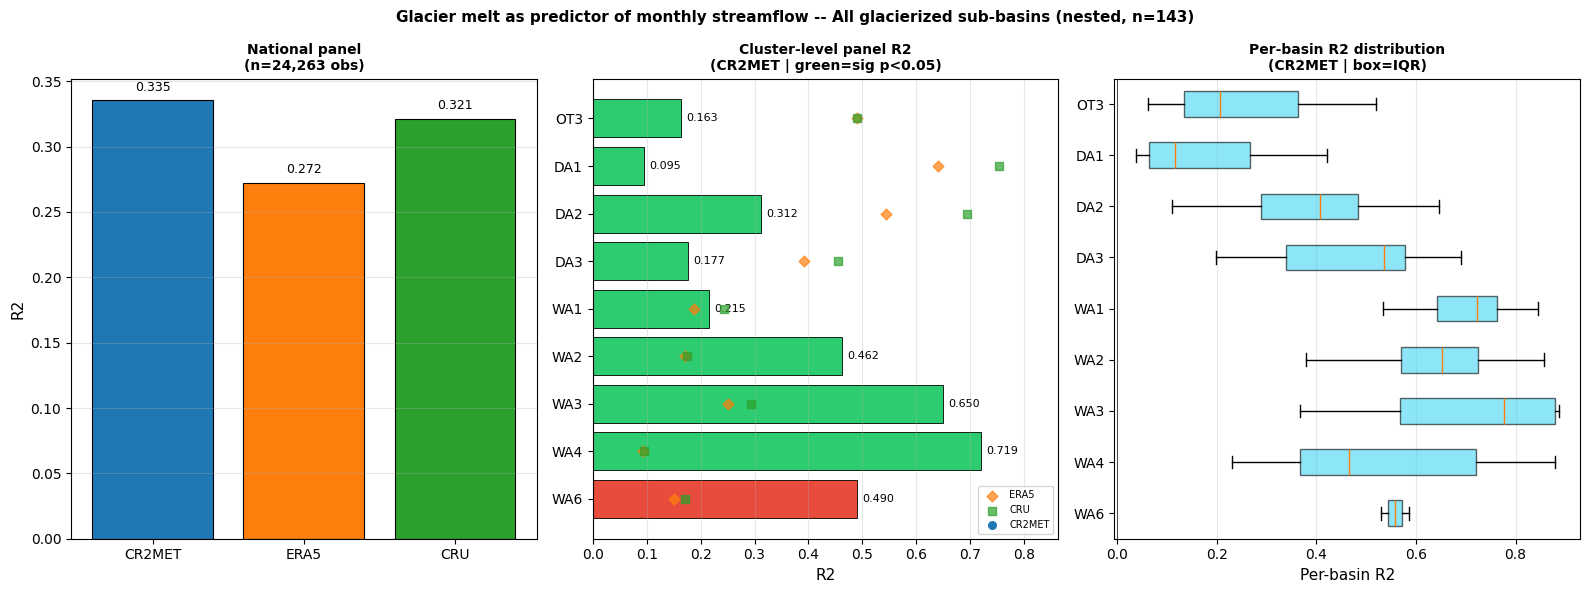

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

ax = axes[0]
datasets = ['CR2MET', 'ERA5', 'CRU']
r2_vals  = [PANEL_RESULTS[ds]['r2'] for ds in datasets]
bars = ax.bar(datasets, r2_vals, color=[DS_COLORS[ds] for ds in datasets], edgecolor='k', linewidth=0.8)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('R2', fontsize=11)
ax.set_title(f'National panel\n(n={PANEL_RESULTS["CR2MET"]["n"]:,} obs)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
cl_r2s  = [CLUSTER_REG['CR2MET'].get(cl, {}).get('r2', np.nan) for cl in CLUSTERS]
cl_sigs = [CLUSTER_REG['CR2MET'].get(cl, {}).get('sig', 'ns') for cl in CLUSTERS]
colors  = ['#2ecc71' if s in ['*','**','***'] else '#e74c3c' for s in cl_sigs]
valid = [(cl, r2, c) for cl, r2, c in zip(CLUSTERS, cl_r2s, colors) if not np.isnan(r2)]
cls_v, r2s_v, cols_v = (list(reversed(x)) for x in zip(*valid)) if valid else ([], [], [])
bars = ax.barh(cls_v, r2s_v, color=cols_v, edgecolor='k', linewidth=0.6)
ax.set_xlabel('R2', fontsize=11)
ax.set_title('Cluster-level panel R2\n(CR2MET | green=sig p<0.05)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
if r2s_v: ax.set_xlim(0, max(r2s_v)*1.2)
for bar, val in zip(bars, r2s_v):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
for ds_name, marker in [('ERA5','D'),('CRU','s')]:
    ds_r2s = [CLUSTER_REG[ds_name].get(cl, {}).get('r2', np.nan) for cl in reversed(cls_v)]
    valid_ds = [(y, r) for y, r in zip(range(len(cls_v)), ds_r2s) if not np.isnan(r)]
    if valid_ds:
        ys, rs = zip(*valid_ds)
        ax.scatter(rs, ys, color=DS_COLORS[ds_name], marker=marker, s=30, zorder=5, alpha=0.7, label=ds_name)
ax.scatter([], [], color=DS_COLORS['CR2MET'], marker='o', s=30, label='CR2MET')
ax.legend(fontsize=7, loc='lower right')

ax = axes[2]
cls_with_data = [cl for cl in CLUSTERS if len(PER_BASIN['CR2MET'][PER_BASIN['CR2MET']['cluster']==cl]) > 0]
cl_data = [PER_BASIN['CR2MET'][PER_BASIN['CR2MET']['cluster']==cl]['r2'].dropna().values for cl in cls_with_data]
cls_box, dat_box = list(reversed(cls_with_data)), list(reversed(cl_data))
if any(len(d) for d in dat_box):
    bp = ax.boxplot(dat_box, labels=cls_box, patch_artist=True, vert=False, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor('#42d4f4'); patch.set_alpha(0.6)
ax.set_xlabel('Per-basin R2', fontsize=11)
ax.set_title('Per-basin R2 distribution\n(CR2MET | box=IQR)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(0, color='k', lw=0.5)

fig.suptitle(f'Glacier melt as predictor of monthly streamflow -- {BASIN_SET_LABEL}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REG_DIR}/r2_across_spatial_scales.png', dpi=150, bbox_inches='tight')
plt.show()


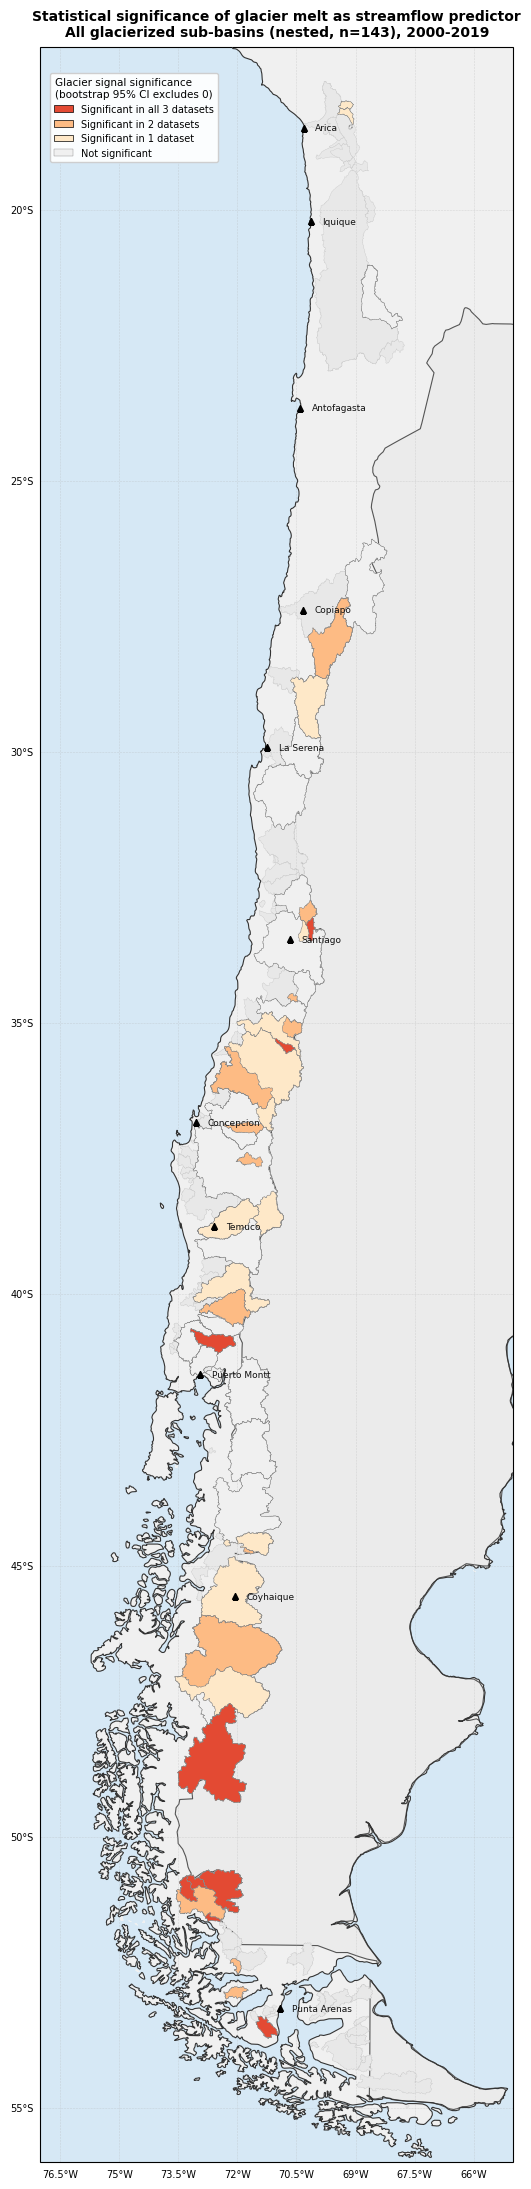

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/regression/all_glacierized/significance_map.png

Robust (all 3 datasets): 11 of 143 basins
Significant in at least 1: 62


In [20]:
# ── Significance map: count of datasets showing significant glacier signal ─
bounds = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)

sig_count = {}
for gauge_id in GAUGE_INFO_FRAC:
    gid = str(gauge_id)
    n = 0
    for ds in ['CR2MET','ERA5','CRU']:
        sub = PER_BASIN[ds][PER_BASIN[ds]['gauge_id'] == gid]
        if len(sub) and sub['sig'].values[0]:
            n += 1
    sig_count[gid] = n

sig_df = pd.DataFrame([{'gauge_id': k, 'n_sig_datasets': v} for k, v in sig_count.items()])
bounds_sig = bounds.merge(sig_df, on='gauge_id', how='left')
sig_colors = {0: '#f0f0f0', 1: '#fee8c8', 2: '#fdbb84', 3: '#e34a33'}

cities = {
    'Arica': (-18.48,-70.32), 'Iquique': (-20.21,-70.14), 'Antofagasta': (-23.65,-70.40),
    'Copiapo': (-27.37,-70.33), 'La Serena': (-29.91,-71.25), 'Santiago': (-33.45,-70.67),
    'Concepcion': (-36.82,-73.05), 'Temuco': (-38.74,-72.59), 'Puerto Montt': (-41.47,-72.94),
    'Coyhaique': (-45.57,-72.07), 'Punta Arenas': (-53.16,-70.91),
}

try:
    world = gpd.read_file('https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    arg = world[world['NAME'] == 'Argentina']
    has_arg = True
except Exception:
    has_arg = False

fig = plt.figure(figsize=(9, 22))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-77, -65, -56, -17], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor='#d6e8f5', zorder=0)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
if has_arg:
    arg.plot(ax=ax, facecolor='#ebebeb', edgecolor='#555555', linewidth=0.8, zorder=1, transform=ccrs.PlateCarree())
bounds_sig.plot(ax=ax, facecolor='#e8e8e8', edgecolor='#cccccc', linewidth=0.2, zorder=2)
for n, color in sig_colors.items():
    subset = bounds_sig[bounds_sig['n_sig_datasets'] == n]
    if len(subset):
        subset.plot(ax=ax, facecolor=color, edgecolor='#888888', linewidth=0.3, zorder=3+n)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#333333', zorder=8)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlabel_style = {'size': 7}; gl.ylabel_style = {'size': 7}
for city, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'k^', markersize=5, zorder=9, transform=ccrs.PlateCarree())
    ax.text(lon+0.3, lat, city, fontsize=6.5, va='center', color='#111111', zorder=9, transform=ccrs.PlateCarree())

handles = [
    Patch(facecolor=sig_colors[3], edgecolor='k', linewidth=0.5, label='Significant in all 3 datasets'),
    Patch(facecolor=sig_colors[2], edgecolor='k', linewidth=0.5, label='Significant in 2 datasets'),
    Patch(facecolor=sig_colors[1], edgecolor='k', linewidth=0.5, label='Significant in 1 dataset'),
    Patch(facecolor=sig_colors[0], edgecolor='#888888', linewidth=0.3, label='Not significant'),
]
ax.legend(handles=handles, loc='upper left', fontsize=7, framealpha=0.93,
          title='Glacier signal significance\n(bootstrap 95% CI excludes 0)',
          title_fontsize=7.5, bbox_to_anchor=(0.01, 0.99))
ax.set_title(f'Statistical significance of glacier melt as streamflow predictor\n'
             f'{BASIN_SET_LABEL}, 2000-2019', fontsize=10, fontweight='bold', pad=8)
plt.tight_layout()
out = f'{REG_DIR}/significance_map.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

n_robust = sum(1 for v in sig_count.values() if v == 3)
n_any    = sum(1 for v in sig_count.values() if v > 0)
print(f'\nRobust (all 3 datasets): {n_robust} of {len(GAUGE_INFO_FRAC)} basins')
print(f'Significant in at least 1: {n_any}')


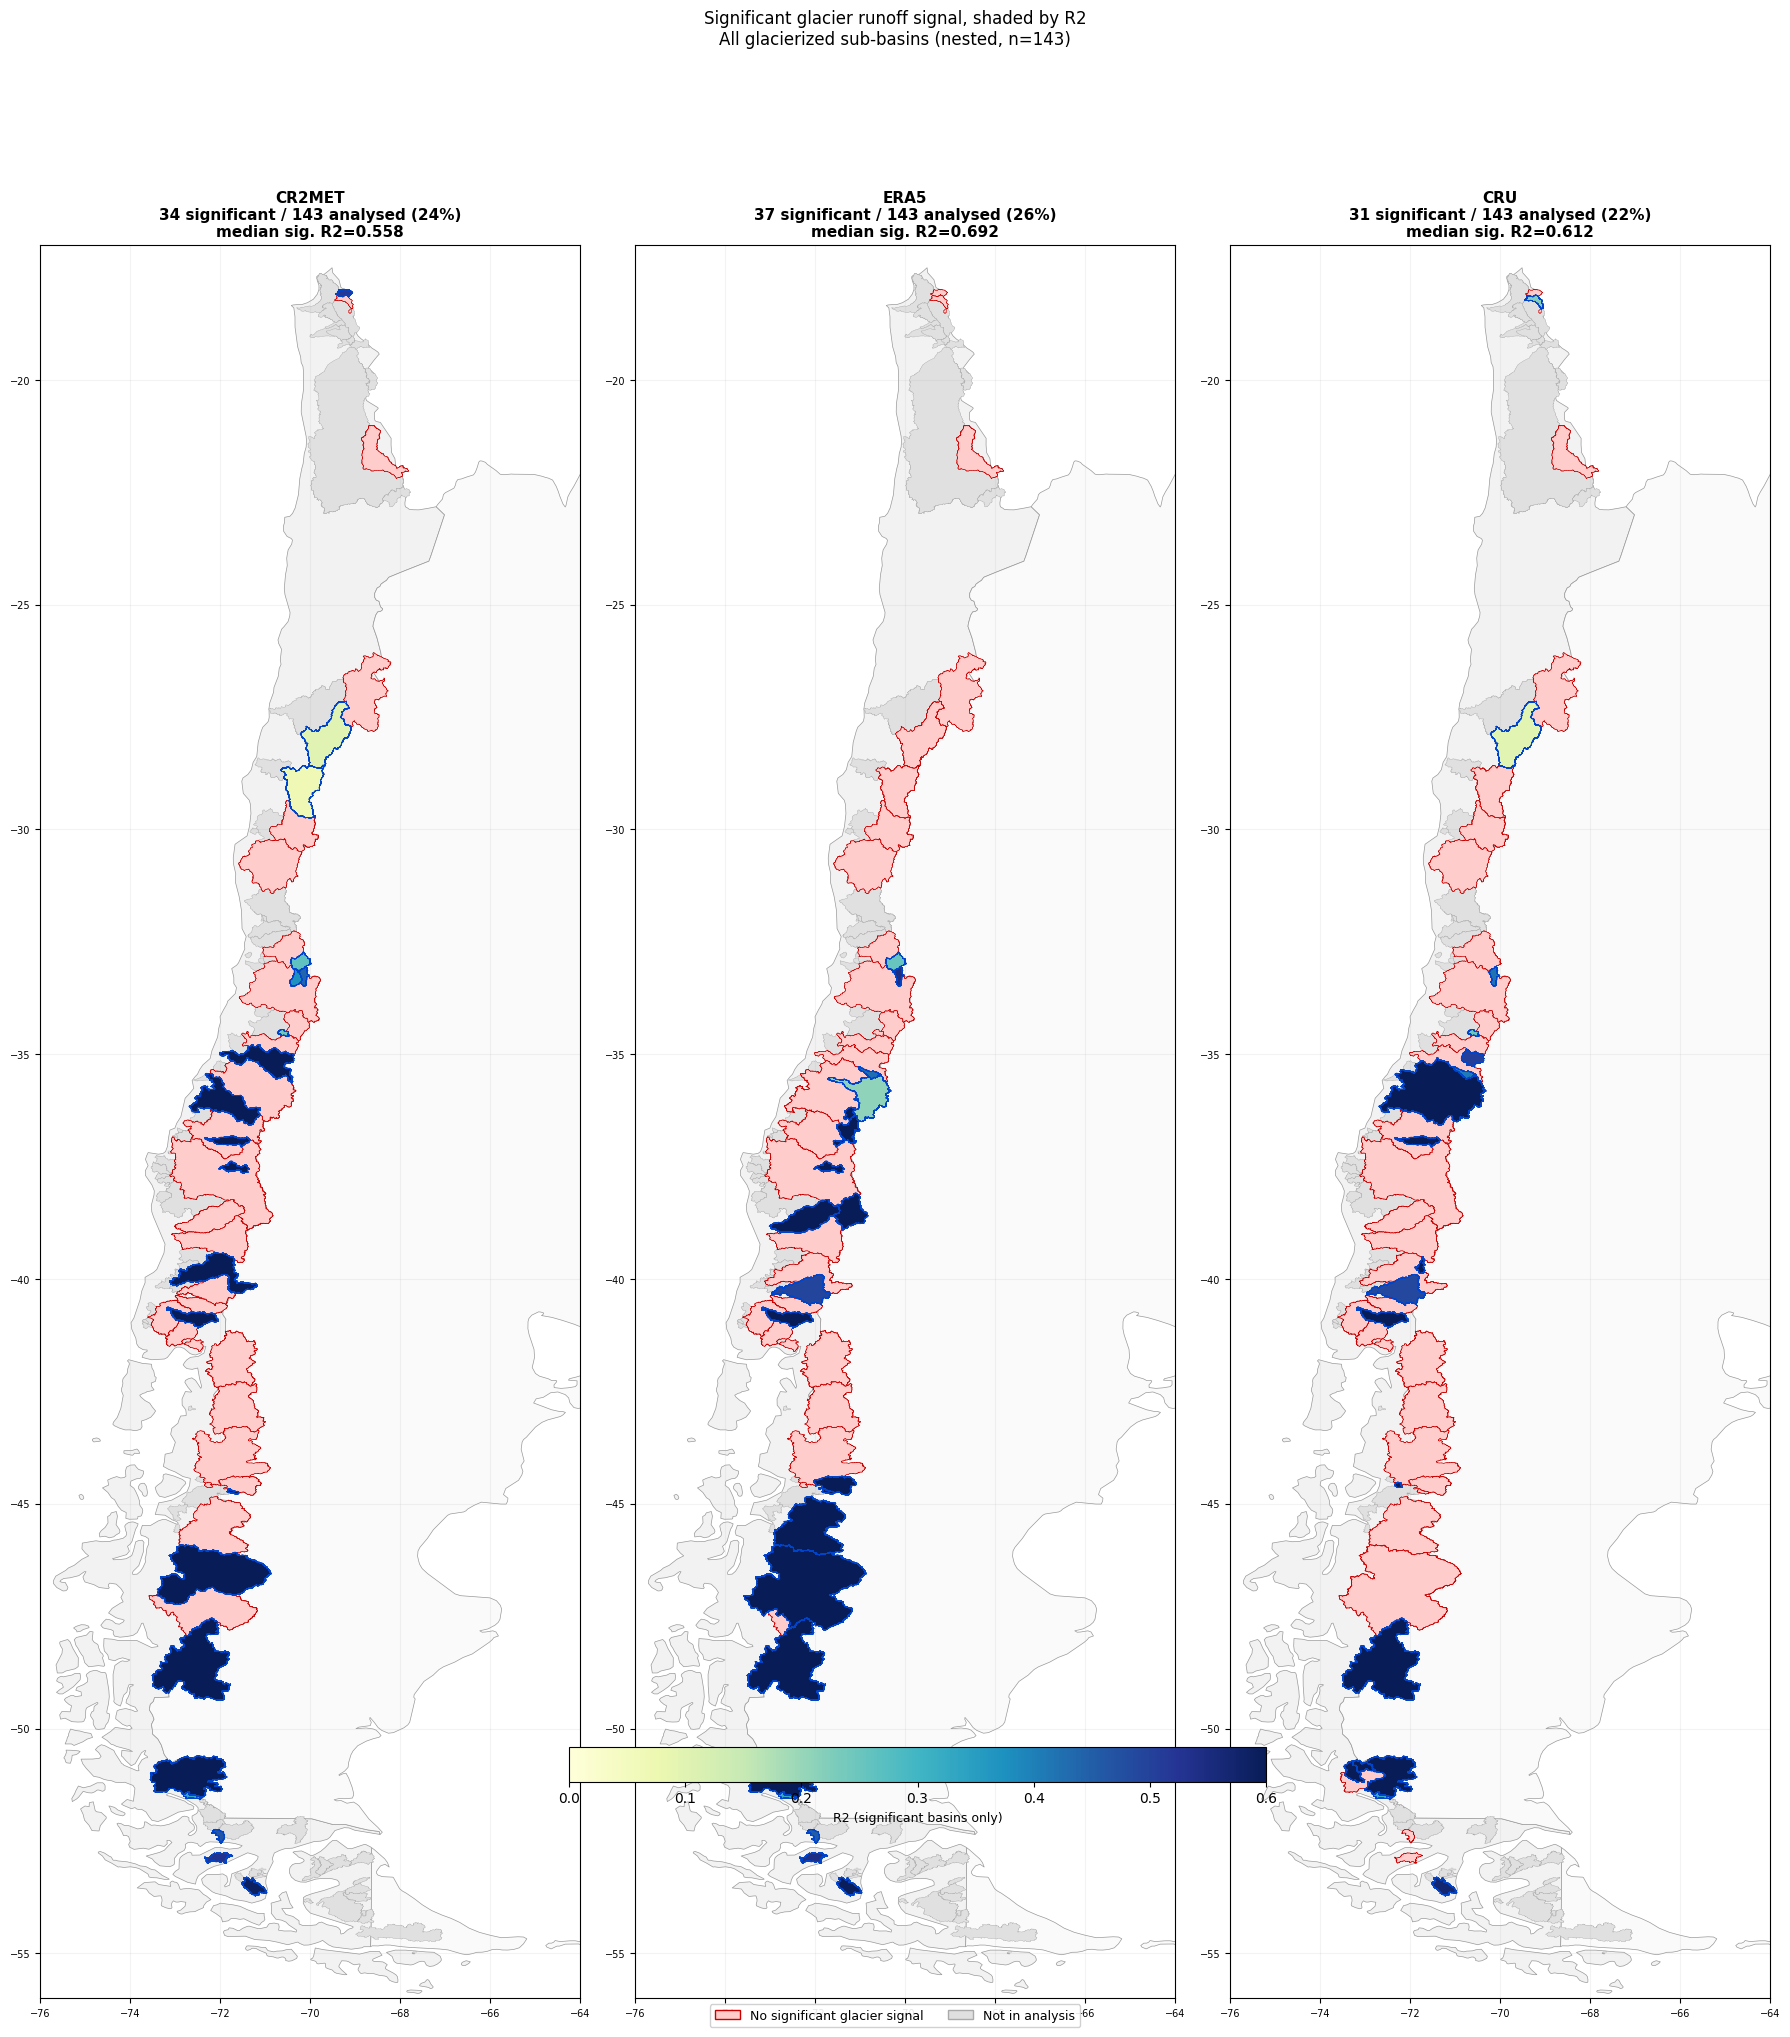

In [21]:
# ── R2-shaded significance map ────────────────────────────────────────────
R2_CMAP = cm.get_cmap('YlGnBu')
R2_NORM = Normalize(vmin=0, vmax=0.6)

fig, axes = plt.subplots(1, 3, figsize=(18, 20))
try:
    world = gpd.read_file('https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile, arg = world[world['NAME']=='Chile'], world[world['NAME']=='Argentina']
    has_borders = True
except Exception:
    has_borders = False

for ax, ds_name in zip(axes, ['CR2MET', 'ERA5', 'CRU']):
    df = PER_BASIN[ds_name].copy()
    df['gauge_id'] = df['gauge_id'].astype(str)
    sig_df, ns_df = df[df['sig']], df[~df['sig']]
    sig_gauges, ns_gauges = set(sig_df['gauge_id']), set(ns_df['gauge_id'])

    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2', edgecolor='#999999', linewidth=0.5, zorder=0)
        arg.plot(ax=ax, facecolor='#fafafa', edgecolor='#999999', linewidth=0.5, zorder=0)

    bounds[bounds['gauge_id'].isin(ns_gauges)].plot(
        ax=ax, facecolor='#ffcccc', edgecolor='#cc0000', linewidth=0.4, zorder=2)
    sig_bounds = bounds[bounds['gauge_id'].isin(sig_gauges)].merge(
        sig_df[['gauge_id','r2']], on='gauge_id', how='left')
    sig_bounds.plot(ax=ax, column='r2', cmap=R2_CMAP, norm=R2_NORM,
                    edgecolor='#0044cc', linewidth=0.6, zorder=3)
    analysed = sig_gauges | ns_gauges
    bounds[~bounds['gauge_id'].isin(analysed)].plot(
        ax=ax, facecolor='#e0e0e0', edgecolor='#aaaaaa', linewidth=0.2, zorder=1)

    ax.set_xlim(-76, -64); ax.set_ylim(-56, -17); ax.set_aspect('equal')
    n_sig, n_tot = len(sig_gauges), len(sig_gauges)+len(ns_gauges)
    med_r2 = sig_df['r2'].median() if len(sig_df) else np.nan
    ax.set_title(f'{ds_name}\n{n_sig} significant / {n_tot} analysed '
                 f'({n_sig/n_tot*100:.0f}%)\nmedian sig. R2={med_r2:.3f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.15); ax.tick_params(labelsize=7)

sm = ScalarMappable(cmap=R2_CMAP, norm=R2_NORM); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.04, shrink=0.5)
cbar.set_label('R2 (significant basins only)', fontsize=9)
fig.legend(handles=[
    Patch(facecolor='#ffcccc', edgecolor='#cc0000', label='No significant glacier signal'),
    Patch(facecolor='#e0e0e0', edgecolor='#aaaaaa', label='Not in analysis'),
], loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.01), framealpha=0.9)
fig.suptitle(f'Significant glacier runoff signal, shaded by R2\n{BASIN_SET_LABEL}', fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig(f'{REG_DIR}/r2_significance_map.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

- **National level:** glacier runoff is a statistically significant
  predictor of monthly streamflow pooled across all basins (R2 varies by
  dataset -- see Section 4 output for the currently-active basin set).
- **Cluster level:** R2 and glacier LMG share vary substantially by
  region -- see Section 5.
- **Basin level:** only a minority of basins show a signal robust across
  all three climate datasets; detectability is driven by hydrological
  context (thermal regime, snow competition, relative glacierization), not
  simply glacier size -- see Section 7's three-mechanism regional synthesis.
- **Lag:** WA1's apparent 5.5-month lag was a seasonal-aliasing artifact;
  genuine routing delays (~1 month) exist in DA2, WA2, WA3, WA4.
- **Noah's question:** see Section 8 for the count/latitude range of small
  glacierized (<=100 km2) gauged basins in the currently-active basin set.

**To compare across basin definitions:** change `BASIN_SET` in Section 1
and rerun top to bottom. Each run's outputs land in a separate
`Output/regression/<BASIN_SET>/` subfolder so results from different runs
don't overwrite each other.
